In [ ]:
!pip install chronos-forecasting "pandas[pyarrow]" requests matplotlib numpy -q

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

In [ ]:
TICKER = "SBER"
DATE_FROM = "2023-01-01"
DATE_TILL = "2024-12-31"
INTERVAL = 24           # дневные свечи
PREDICTION_LENGTH = 30   # 30 дней вперёд
QUANTILES = [0.1, 0.5, 0.9]

In [ ]:
def fetch_moex_candles(ticker, date_from, date_till, interval):
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json"
    all_rows = []
    start = 0
    while True:
        params = {"from": date_from, "till": date_till, "interval": interval, "start": start}
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        cols = data["candles"]["columns"]
        rows = data["candles"]["data"]
        if not rows:
            break
        all_rows.extend(rows)
        if len(rows) < 500:
            break
        start += len(rows)
    df = pd.DataFrame(all_rows, columns=cols)
    df["begin"] = pd.to_datetime(df["begin"])
    return df.sort_values("begin").reset_index(drop=True)

df = fetch_moex_candles(TICKER, DATE_FROM, DATE_TILL, INTERVAL)
print(f"Получено {len(df)} свечей")
df.head()

Получено 510 свечей


,open,close,high,low,value,volume,begin,end
0,141.60,141.78,143.25,141.56,3.000248e+09,21098550,2023-01-03,2023-01-03 23:59:59
1,141.85,141.43,142.28,140.75,2.419429e+09,17112740,2023-01-04,2023-01-04 23:59:59
2,141.60,141.27,141.84,140.54,2.435171e+09,17245300,2023-01-05,2023-01-05 23:59:59
3,141.39,141.40,141.62,140.90,1.504731e+09,10657600,2023-01-06,2023-01-06 23:59:59
4,141.83,142.40,142.99,141.65,4.480148e+09,31449160,2023-01-09,2023-01-09 23:59:59


In [ ]:
context_df = df.iloc[:-PREDICTION_LENGTH].copy()
test_df = df.iloc[-PREDICTION_LENGTH:].copy()

print(f"Контекст: {len(context_df)} свечей ({context_df['begin'].min().date()} → {context_df['begin'].max().date()})")
print(f"Тест:     {len(test_df)} свечей ({test_df['begin'].min().date()} → {test_df['begin'].max().date()})")

Контекст: 480 свечей (2023-01-03 → 2024-11-19)
Тест:     30 свечей (2024-11-20 → 2024-12-30)


In [ ]:
context_input = pd.DataFrame({
    "id": TICKER,
    "timestamp": context_df["begin"].values,
    "target": context_df["close"].astype(float).values,
})
context_input.tail()

,id,timestamp,target
475,SBER,2024-11-13,254.70
476,SBER,2024-11-14,249.52
477,SBER,2024-11-15,253.43
478,SBER,2024-11-18,248.72
479,SBER,2024-11-19,240.59


In [ ]:
# device_map="cuda" если есть GPU, иначе "cpu"
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")
print("Модель загружена ✓")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Модель загружена ✓


In [ ]:
# Создаём регулярный business-day индекс и заполняем пропуски (праздники)
ts = (
    context_df.set_index("begin")["close"]
    .astype(float)
    .asfreq("B")              # business day frequency
    .ffill()                  # пропуски (праздники МосБиржи) -> предыдущая цена
)

context_input = pd.DataFrame({
    "id": TICKER,
    "timestamp": ts.index,
    "target": ts.values,
})

# проверка
print("Частота:", pd.infer_freq(context_input["timestamp"]))
print(f"Точек: {len(context_input)}")
context_input.tail()

Частота: B
Точек: 491


,id,timestamp,target
486,SBER,2024-11-13,254.70
487,SBER,2024-11-14,249.52
488,SBER,2024-11-15,253.43
489,SBER,2024-11-18,248.72
490,SBER,2024-11-19,240.59


In [ ]:
test_ts = (
    test_df.set_index("begin")["close"]
    .astype(float)
    .asfreq("B")
    .ffill()
)
test_aligned = pd.DataFrame({
    "timestamp": test_ts.index,
    "close": test_ts.values,
})
print(f"Test после выравнивания: {len(test_aligned)} точек")
test_aligned.head()

Test после выравнивания: 29 точек


,timestamp,close
0,2024-11-20,237.05
1,2024-11-21,240.47
2,2024-11-22,236.00
3,2024-11-25,227.81
4,2024-11-26,223.16


In [ ]:
pred_df = pipeline.predict_df(
    context_input,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=QUANTILES,
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)
pred_df.head()

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,SBER,2024-11-20,target,239.367310,234.009460,239.367310,244.333069
1,SBER,2024-11-21,target,238.980316,231.442505,238.980316,247.229263
2,SBER,2024-11-22,target,238.491577,228.998245,238.491577,248.491165
3,SBER,2024-11-25,target,238.412842,227.443390,238.412842,249.731049
4,SBER,2024-11-26,target,238.152451,225.445953,238.152451,250.810776


In [ ]:
# Объединяем прогноз с фактом по timestamp (важно — после выравнивания на B-частоту)
merged = pred_df.merge(
    test_aligned.rename(columns={"close": "y_true"}),
    on="timestamp",
    how="inner",
)

y_true = merged["y_true"].values
y_pred = merged["0.5"].values  # медианный прогноз

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Direction Accuracy — главная метрика для трейдинга
true_dir = np.sign(np.diff(y_true))
pred_dir = np.sign(np.diff(y_pred))
dir_acc = (true_dir == pred_dir).mean() * 100

# Покрытие коридором: сколько фактов попало в [0.1, 0.9]
coverage = ((y_true >= merged["0.1"]) & (y_true <= merged["0.9"])).mean() * 100

print(f"=== Chronos-2 zero-shot на {TICKER} ===")
print(f"Точек сравнения:  {len(merged)}")
print(f"MAE:              {mae:.2f} руб")
print(f"RMSE:             {rmse:.2f} руб")
print(f"MAPE:             {mape:.2f} %")
print(f"Direction Acc:    {dir_acc:.1f} %")
print(f"Coverage 10-90%:  {coverage:.1f} %  (в идеале ~80%)")

=== Chronos-2 zero-shot на SBER ===
Точек сравнения:  29
MAE:              12.98 руб
RMSE:             17.50 руб
MAPE:             5.17 %
Direction Acc:    57.1 %
Coverage 10-90%:  75.9 %  (в идеале ~80%)


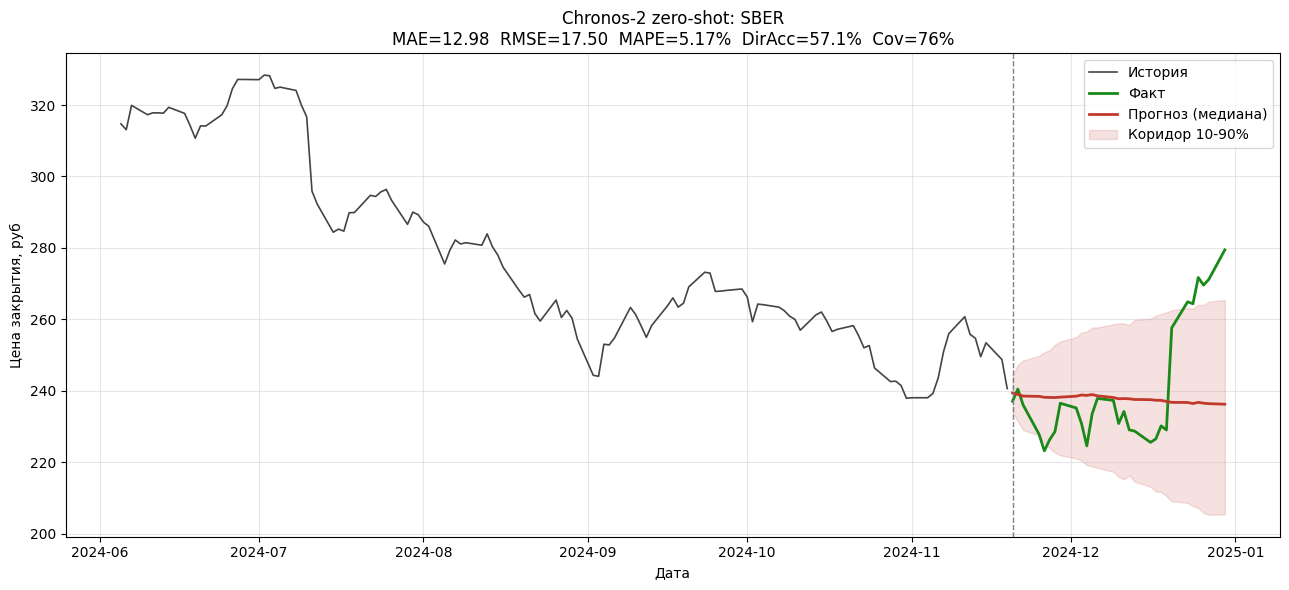

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

# История (последние 120 точек контекста для читаемости)
hist = context_input.tail(120)
ax.plot(hist["timestamp"], hist["target"], label="История", color="#444", lw=1.2)

# Факт на горизонте
ax.plot(merged["timestamp"], merged["y_true"], label="Факт", color="#1a8917", lw=2)

# Медианный прогноз
ax.plot(merged["timestamp"], merged["0.5"], label="Прогноз (медиана)", color="#c0392b", lw=2)

# Квантильный коридор
ax.fill_between(
    merged["timestamp"],
    merged["0.1"], merged["0.9"],
    color="#c0392b", alpha=0.15,
    label="Коридор 10-90%",
)

ax.axvline(merged["timestamp"].iloc[0], color="gray", ls="--", lw=1)
ax.set_title(
    f"Chronos-2 zero-shot: {TICKER}\n"
    f"MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%  DirAcc={dir_acc:.1f}%  Cov={coverage:.0f}%"
)
ax.set_xlabel("Дата")
ax.set_ylabel("Цена закрытия, руб")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Горизонт 5 дней ===
MAE=12.07  RMSE=12.78  MAPE=4.40%  DirAcc=33.3%  Cov=50%


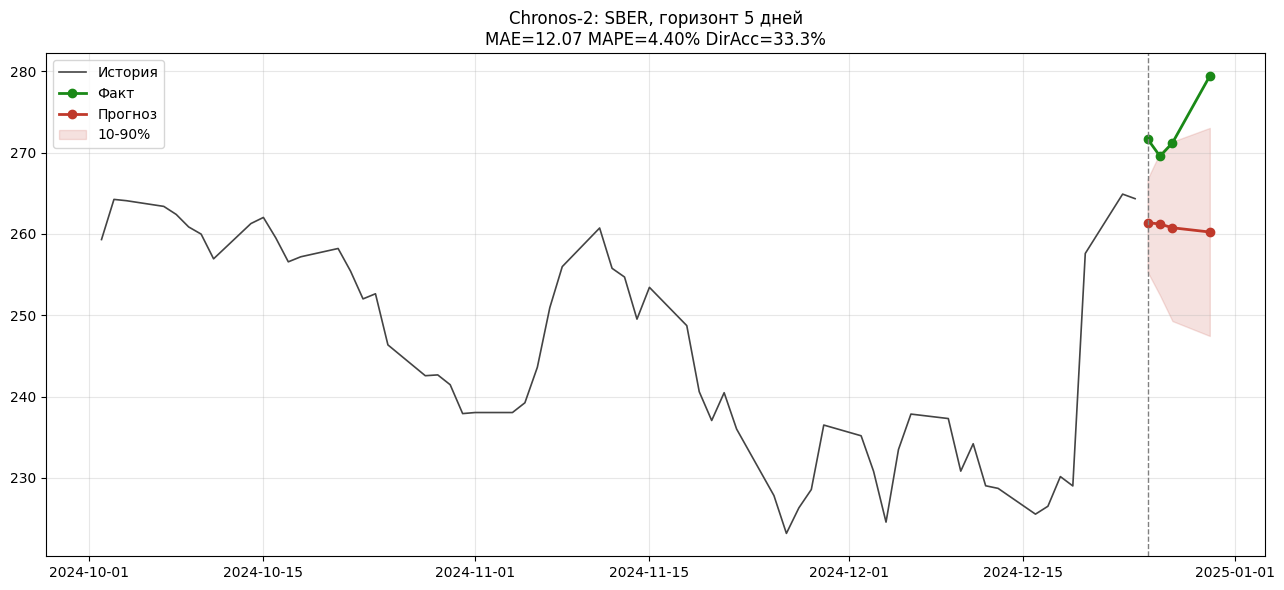

In [ ]:
PREDICTION_LENGTH = 5

# Пересобираем split
context_df = df.iloc[:-PREDICTION_LENGTH].copy()
test_df = df.iloc[-PREDICTION_LENGTH:].copy()

# Контекст с регулярной частотой
ts = (
    context_df.set_index("begin")["close"]
    .astype(float)
    .asfreq("B")
    .ffill()
)
context_input = pd.DataFrame({
    "id": TICKER,
    "timestamp": ts.index,
    "target": ts.values,
})

# Тест с регулярной частотой
test_ts = (
    test_df.set_index("begin")["close"]
    .astype(float)
    .asfreq("B")
    .ffill()
)
test_aligned = pd.DataFrame({
    "timestamp": test_ts.index,
    "close": test_ts.values,
})

# Прогноз
pred_df = pipeline.predict_df(
    context_input,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=QUANTILES,
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

# Метрики
merged = pred_df.merge(
    test_aligned.rename(columns={"close": "y_true"}),
    on="timestamp", how="inner",
)
y_true = merged["y_true"].values
y_pred = merged["0.5"].values

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
true_dir = np.sign(np.diff(y_true))
pred_dir = np.sign(np.diff(y_pred))
dir_acc = (true_dir == pred_dir).mean() * 100 if len(true_dir) > 0 else 0
coverage = ((y_true >= merged["0.1"]) & (y_true <= merged["0.9"])).mean() * 100

print(f"=== Горизонт {PREDICTION_LENGTH} дней ===")
print(f"MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%  DirAcc={dir_acc:.1f}%  Cov={coverage:.0f}%")

# График
fig, ax = plt.subplots(figsize=(13, 6))
hist = context_input.tail(60)
ax.plot(hist["timestamp"], hist["target"], label="История", color="#444", lw=1.2)
ax.plot(merged["timestamp"], merged["y_true"], label="Факт", color="#1a8917", lw=2, marker="o")
ax.plot(merged["timestamp"], merged["0.5"], label="Прогноз", color="#c0392b", lw=2, marker="o")
ax.fill_between(merged["timestamp"], merged["0.1"], merged["0.9"], color="#c0392b", alpha=0.15, label="10-90%")
ax.axvline(merged["timestamp"].iloc[0], color="gray", ls="--", lw=1)
ax.set_title(f"Chronos-2: {TICKER}, горизонт {PREDICTION_LENGTH} дней\nMAE={mae:.2f} MAPE={mape:.2f}% DirAcc={dir_acc:.1f}%")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
from tqdm import tqdm

# === Параметры ===
N_WINDOWS = 50              # сколько окон тестируем
HORIZON = 5                 # горизонт прогноза в днях
CONTEXT_LEN = 250           # сколько точек истории даём модели на каждое окно

# Готовим единый ряд с регулярной частотой (один раз)
full_ts = (
    df.set_index("begin")["close"]
    .astype(float)
    .asfreq("B")
    .ffill()
)
print(f"Всего точек после выравнивания: {len(full_ts)}")
print(f"Нужно минимум: {CONTEXT_LEN + HORIZON + N_WINDOWS} точек")

# === Прогон по окнам ===
results = []  # сюда складываем метрики каждого окна

# Окна идут с конца ряда к началу: последнее окно = последние HORIZON точек
for i in tqdm(range(N_WINDOWS), desc="Walk-forward"):
    end_idx = len(full_ts) - i           # правая граница (не включая)
    test_start = end_idx - HORIZON
    ctx_start = test_start - CONTEXT_LEN
    if ctx_start < 0:
        print(f"Не хватило истории на окно {i}, останавливаемся")
        break

    ctx_slice = full_ts.iloc[ctx_start:test_start]
    test_slice = full_ts.iloc[test_start:end_idx]

    ctx_input = pd.DataFrame({
        "id": TICKER,
        "timestamp": ctx_slice.index,
        "target": ctx_slice.values,
    })

    pred = pipeline.predict_df(
        ctx_input,
        prediction_length=HORIZON,
        quantile_levels=QUANTILES,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )

    y_true = test_slice.values
    y_pred = pred["0.5"].values

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Direction Accuracy: сравниваем знак изменения от последней точки контекста
    last_ctx = ctx_slice.values[-1]
    true_dir = np.sign(np.diff(np.concatenate([[last_ctx], y_true])))
    pred_dir = np.sign(np.diff(np.concatenate([[last_ctx], y_pred])))
    dir_acc = (true_dir == pred_dir).mean() * 100

    coverage = ((y_true >= pred["0.1"].values) & (y_true <= pred["0.9"].values)).mean() * 100

    results.append({
        "window": i,
        "test_start": test_slice.index[0],
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "dir_acc": dir_acc,
        "coverage": coverage,
    })

results_df = pd.DataFrame(results)
print(f"\nПрогнано окон: {len(results_df)}")
results_df.head()

Всего точек после выравнивания: 520
Нужно минимум: 305 точек


Walk-forward: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s]



Прогнано окон: 50


,window,test_start,mae,rmse,mape,dir_acc,coverage
0,0,2024-12-24,6.706004,8.288041,2.441257,60.0,80.0
1,1,2024-12-23,8.028375,8.563067,2.979410,40.0,100.0
2,2,2024-12-20,35.949396,36.321670,13.502734,40.0,0.0
3,3,2024-12-19,27.490729,30.596982,10.389187,40.0,20.0
4,4,2024-12-18,21.981411,27.438361,8.418511,80.0,40.0


In [ ]:
print("=== Walk-forward результаты ===\n")
print(f"Тикер: {TICKER}, окон: {len(results_df)}, горизонт: {HORIZON} дней")
print()
print(f"{'Метрика':<15} {'Среднее':>10} {'Медиана':>10} {'Мин':>10} {'Макс':>10} {'Std':>10}")
print("-" * 70)
for col in ["mae", "rmse", "mape", "dir_acc", "coverage"]:
    s = results_df[col]
    print(f"{col:<15} {s.mean():>10.2f} {s.median():>10.2f} {s.min():>10.2f} {s.max():>10.2f} {s.std():>10.2f}")

# % окон где DirAcc > 50% (лучше монетки)
better_than_random = (results_df["dir_acc"] > 50).mean() * 100
print(f"\nДоля окон с DirAcc > 50%: {better_than_random:.0f}%")
print(f"Доля окон с DirAcc > 60%: {(results_df['dir_acc'] > 60).mean() * 100:.0f}%")

=== Walk-forward результаты ===

Тикер: SBER, окон: 50, горизонт: 5 дней

Метрика            Среднее    Медиана        Мин       Макс        Std
----------------------------------------------------------------------
mae                   8.58       7.16       1.85      35.95       6.29
rmse                  9.83       8.25       2.35      36.32       6.91
mape                  3.48       2.91       0.82      13.50       2.38
dir_acc              44.80      40.00      20.00      80.00      17.87
coverage             63.60      80.00       0.00     100.00      33.97

Доля окон с DirAcc > 50%: 38%
Доля окон с DirAcc > 60%: 8%


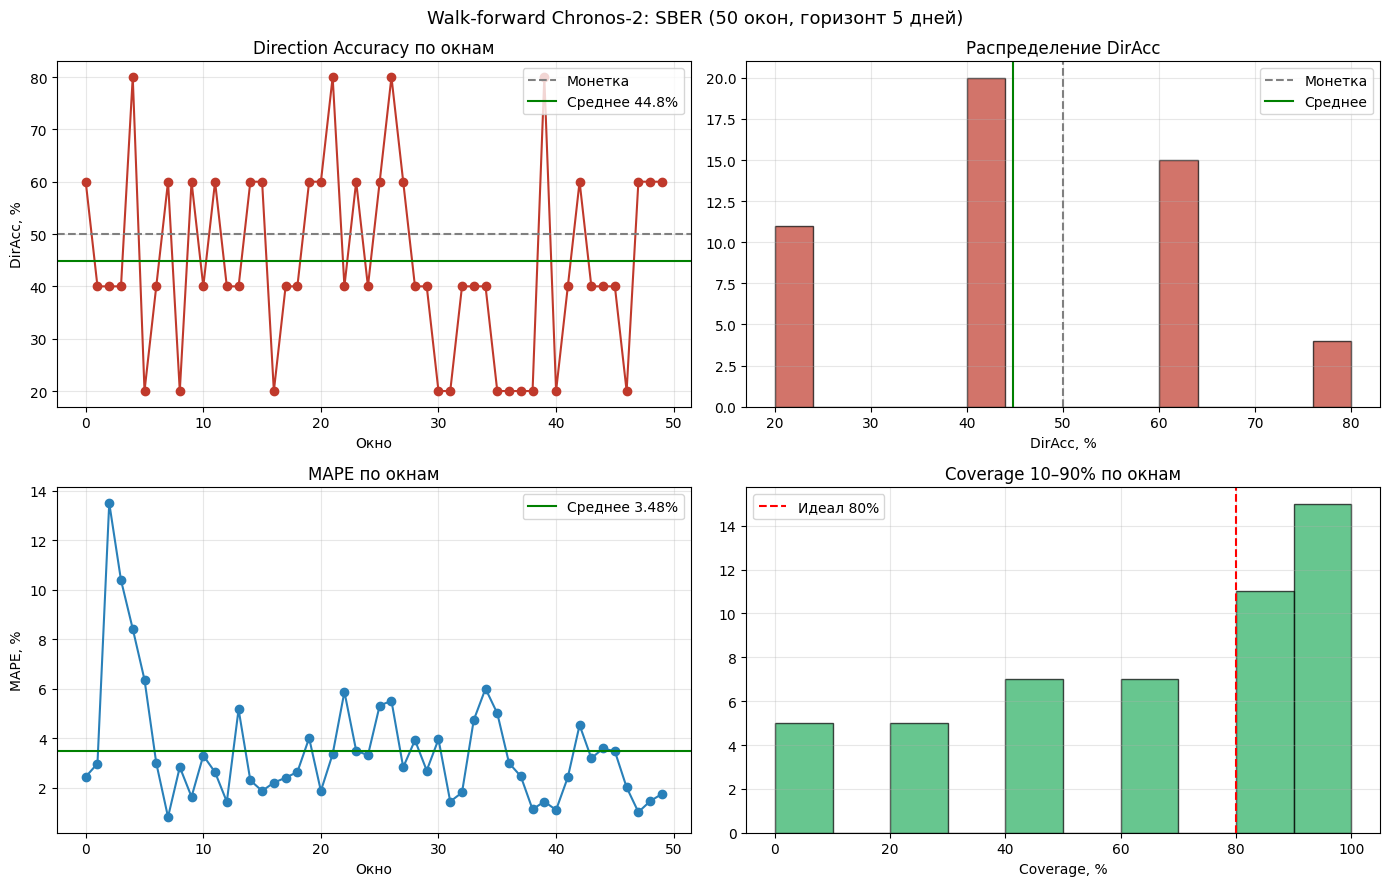

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. DirAcc по окнам
axes[0, 0].plot(results_df["window"], results_df["dir_acc"], marker="o", color="#c0392b")
axes[0, 0].axhline(50, color="gray", ls="--", label="Монетка")
axes[0, 0].axhline(results_df["dir_acc"].mean(), color="green", ls="-", label=f"Среднее {results_df['dir_acc'].mean():.1f}%")
axes[0, 0].set_title("Direction Accuracy по окнам")
axes[0, 0].set_xlabel("Окно")
axes[0, 0].set_ylabel("DirAcc, %")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2. Гистограмма DirAcc
axes[0, 1].hist(results_df["dir_acc"], bins=15, color="#c0392b", alpha=0.7, edgecolor="black")
axes[0, 1].axvline(50, color="gray", ls="--", label="Монетка")
axes[0, 1].axvline(results_df["dir_acc"].mean(), color="green", ls="-", label="Среднее")
axes[0, 1].set_title("Распределение DirAcc")
axes[0, 1].set_xlabel("DirAcc, %"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# 3. MAPE по окнам
axes[1, 0].plot(results_df["window"], results_df["mape"], marker="o", color="#2980b9")
axes[1, 0].axhline(results_df["mape"].mean(), color="green", ls="-", label=f"Среднее {results_df['mape'].mean():.2f}%")
axes[1, 0].set_title("MAPE по окнам")
axes[1, 0].set_xlabel("Окно"); axes[1, 0].set_ylabel("MAPE, %")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 4. Coverage
axes[1, 1].hist(results_df["coverage"], bins=10, color="#27ae60", alpha=0.7, edgecolor="black")
axes[1, 1].axvline(80, color="red", ls="--", label="Идеал 80%")
axes[1, 1].set_title("Coverage 10–90% по окнам")
axes[1, 1].set_xlabel("Coverage, %"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle(f"Walk-forward Chronos-2: {TICKER} ({len(results_df)} окон, горизонт {HORIZON} дней)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def fetch_moex_futures(ticker, date_from, date_till, interval=24):
    """Свечи фьючерсов с MOEX (рынок forts). BR=нефть, Si=USD/RUB."""
    url = f"https://iss.moex.com/iss/engines/futures/markets/forts/securities/{ticker}/candles.json"
    all_rows, start = [], 0
    while True:
        params = {"from": date_from, "till": date_till, "interval": interval, "start": start}
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        cols, rows = data["candles"]["columns"], data["candles"]["data"]
        if not rows:
            break
        all_rows.extend(rows)
        if len(rows) < 500:
            break
        start += len(rows)
    df = pd.DataFrame(all_rows, columns=cols)
    df["begin"] = pd.to_datetime(df["begin"])
    return df.sort_values("begin").reset_index(drop=True)


def fetch_moex_index(ticker, date_from, date_till, interval=24):
    """Свечи индекса (рынок index). IMOEX=индекс Мосбиржи."""
    url = f"https://iss.moex.com/iss/engines/stock/markets/index/securities/{ticker}/candles.json"
    all_rows, start = [], 0
    while True:
        params = {"from": date_from, "till": date_till, "interval": interval, "start": start}
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        cols, rows = data["candles"]["columns"], data["candles"]["data"]
        if not rows:
            break
        all_rows.extend(rows)
        if len(rows) < 500:
            break
        start += len(rows)
    df = pd.DataFrame(all_rows, columns=cols)
    df["begin"] = pd.to_datetime(df["begin"])
    return df.sort_values("begin").reset_index(drop=True)


print("Тянем IMOEX...")
imoex = fetch_moex_index("IMOEX", DATE_FROM, DATE_TILL)
print(f"  {len(imoex)} свечей")

print("Тянем MOEXOG (нефть и газ)...")
moexog = fetch_moex_index("MOEXOG", DATE_FROM, DATE_TILL)
print(f"  {len(moexog)} свечей")

print("Тянем MOEXFN (финансовый сектор)...")
moexfn = fetch_moex_index("MOEXFN", DATE_FROM, DATE_TILL)
print(f"  {len(moexfn)} свечей")

print("Тянем RGBI (индекс гособлигаций)...")
rgbi = fetch_moex_index("RGBI", DATE_FROM, DATE_TILL)
print(f"  {len(rgbi)} свечей")

print(f"Объём SBER уже есть в df ({len(df)} свечей)")

Тянем IMOEX...
  510 свечей
Тянем MOEXOG (нефть и газ)...
  510 свечей
Тянем MOEXFN (финансовый сектор)...
  510 свечей
Тянем RGBI (индекс гособлигаций)...
  510 свечей
Объём SBER уже есть в df (510 свечей)


In [ ]:
target_ts = to_bday_series(df, "close", "target")
cov_volume = to_bday_series(df, "volume", "sber_volume")
cov_imoex = to_bday_series(imoex, "close", "imoex")
cov_moexog = to_bday_series(moexog, "close", "moexog")
cov_moexfn = to_bday_series(moexfn, "close", "moexfn")
cov_rgbi = to_bday_series(rgbi, "close", "rgbi")

all_data = pd.concat(
    [target_ts, cov_volume, cov_imoex, cov_moexog, cov_moexfn, cov_rgbi],
    axis=1,
).dropna()

print(f"Общих точек: {len(all_data)}")
print(f"Колонки: {list(all_data.columns)}")
all_data.head()

Общих точек: 520
Колонки: ['target', 'sber_volume', 'imoex', 'moexog', 'moexfn', 'rgbi']


,target,sber_volume,imoex,moexog,moexfn,rgbi
begin,,,,,,
2023-01-03,141.78,21098550.0,2172.68,5705.97,6312.39,130.91
2023-01-04,141.43,17112740.0,2168.42,5670.73,6297.52,131.11
2023-01-05,141.27,17245300.0,2156.67,5649.59,6299.76,131.26
2023-01-06,141.40,10657600.0,2156.39,5651.65,6270.56,131.16
2023-01-09,142.40,31449160.0,2163.50,5650.93,6338.24,130.61


In [ ]:
COVARIATES = ["sber_volume", "imoex", "moexog", "moexfn", "rgbi"]

In [ ]:
from tqdm import tqdm

N_WINDOWS = 50
HORIZON = 5
CONTEXT_LEN = 250
COVARIATES = ["sber_volume", "imoex", "moexog", "moexfn", "rgbi"]

results_baseline = []
results_covariates = []

for i in tqdm(range(N_WINDOWS), desc="A/B walk-forward"):
    end_idx = len(all_data) - i
    test_start = end_idx - HORIZON
    ctx_start = test_start - CONTEXT_LEN
    if ctx_start < 0:
        print(f"Не хватило истории, остановились на окне {i}")
        break

    ctx_slice = all_data.iloc[ctx_start:test_start]
    test_slice = all_data.iloc[test_start:end_idx]
    last_ctx = ctx_slice["target"].values[-1]
    y_true = test_slice["target"].values

    # === Run A: baseline (только цена) ===
    ctx_a = pd.DataFrame({
        "id": TICKER,
        "timestamp": ctx_slice.index,
        "target": ctx_slice["target"].values,
    })
    pred_a = pipeline.predict_df(
        ctx_a,
        prediction_length=HORIZON,
        quantile_levels=QUANTILES,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )
    y_pred_a = pred_a["0.5"].values

    # === Run B: с ковариатами (past-only) ===
    ctx_b = pd.DataFrame({
        "id": TICKER,
        "timestamp": ctx_slice.index,
        "target": ctx_slice["target"].values,
    })
    for cov in COVARIATES:
        ctx_b[cov] = ctx_slice[cov].values

    pred_b = pipeline.predict_df(
        ctx_b,
        prediction_length=HORIZON,
        quantile_levels=QUANTILES,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )
    y_pred_b = pred_b["0.5"].values

    # === Метрики для обоих ===
    for y_pred, store in [(y_pred_a, results_baseline), (y_pred_b, results_covariates)]:
        mae = np.mean(np.abs(y_true - y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        true_dir = np.sign(np.diff(np.concatenate([[last_ctx], y_true])))
        pred_dir = np.sign(np.diff(np.concatenate([[last_ctx], y_pred])))
        dir_acc = (true_dir == pred_dir).mean() * 100
        store.append({"window": i, "mae": mae, "mape": mape, "dir_acc": dir_acc})

res_a = pd.DataFrame(results_baseline)
res_b = pd.DataFrame(results_covariates)
print(f"\nГотово: {len(res_a)} окон")

A/B walk-forward: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


Готово: 50 окон


A/B сравнение Chronos-2: baseline vs +ковариаты (50 окон)

Метрика             Baseline     +Covariates     Дельта
------------------------------------------------------------
mae                     8.58            8.47      -0.11  ✓ лучше
mape                    3.48            3.44      -0.04  ✓ лучше
dir_acc                44.80           44.40      -0.40  ✗ хуже

Доля окон по DirAcc:
  ковариаты улучшили: 28%
  ковариаты ухудшили: 30%
  без изменений:      42%


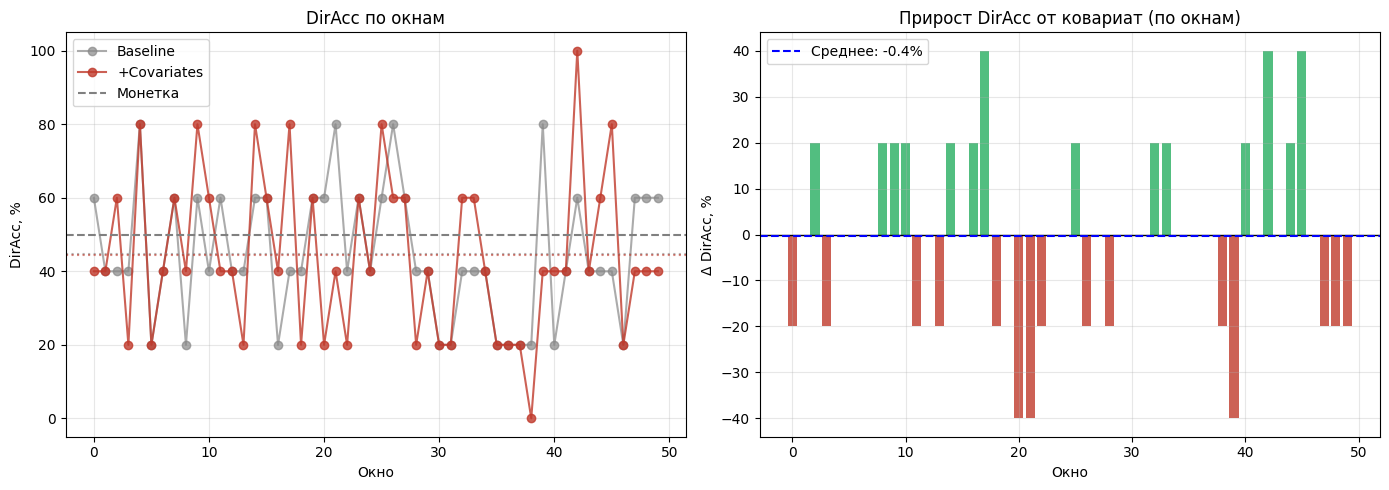

In [ ]:
print("=" * 60)
print(f"A/B сравнение Chronos-2: baseline vs +ковариаты ({len(res_a)} окон)")
print("=" * 60)
print(f"\n{'Метрика':<15} {'Baseline':>12} {'+Covariates':>15} {'Дельта':>10}")
print("-" * 60)
for col in ["mae", "mape", "dir_acc"]:
    a, b = res_a[col].mean(), res_b[col].mean()
    delta = b - a
    is_better = (col == "dir_acc" and delta > 0) or (col != "dir_acc" and delta < 0)
    arrow = "✓ лучше" if is_better else "✗ хуже"
    print(f"{col:<15} {a:>12.2f} {b:>15.2f} {delta:>+10.2f}  {arrow}")

improved = ((res_b['dir_acc'] - res_a['dir_acc']) > 0).mean() * 100
worse = ((res_b['dir_acc'] - res_a['dir_acc']) < 0).mean() * 100
same = 100 - improved - worse
print(f"\nДоля окон по DirAcc:")
print(f"  ковариаты улучшили: {improved:.0f}%")
print(f"  ковариаты ухудшили: {worse:.0f}%")
print(f"  без изменений:      {same:.0f}%")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(res_a["window"], res_a["dir_acc"], "o-", label="Baseline", color="#888", alpha=0.7)
axes[0].plot(res_b["window"], res_b["dir_acc"], "o-", label="+Covariates", color="#c0392b", alpha=0.8)
axes[0].axhline(50, color="gray", ls="--", label="Монетка")
axes[0].axhline(res_a["dir_acc"].mean(), color="#888", ls=":", alpha=0.6)
axes[0].axhline(res_b["dir_acc"].mean(), color="#c0392b", ls=":", alpha=0.6)
axes[0].set_title("DirAcc по окнам")
axes[0].set_xlabel("Окно"); axes[0].set_ylabel("DirAcc, %")
axes[0].legend(); axes[0].grid(alpha=0.3)

diff = res_b["dir_acc"] - res_a["dir_acc"]
colors = ["#27ae60" if d > 0 else ("#c0392b" if d < 0 else "#aaa") for d in diff]
axes[1].bar(res_b["window"], diff, color=colors, alpha=0.8)
axes[1].axhline(0, color="black", lw=1)
axes[1].axhline(diff.mean(), color="blue", ls="--", label=f"Среднее: {diff.mean():+.1f}%")
axes[1].set_title("Прирост DirAcc от ковариат (по окнам)")
axes[1].set_xlabel("Окно"); axes[1].set_ylabel("Δ DirAcc, %")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
from tqdm import tqdm

N_WINDOWS = 50
HORIZON = 5
CONTEXT_LEN = 250

# Готовим ряд log-returns
prices = all_data["target"]
log_returns = np.log(prices / prices.shift(1)).dropna()
print(f"Log-returns: {len(log_returns)} точек")
print(f"Среднее: {log_returns.mean():.5f}, std: {log_returns.std():.5f}")

results_returns = []

for i in tqdm(range(N_WINDOWS), desc="Walk-forward returns"):
    end_idx = len(log_returns) - i
    test_start = end_idx - HORIZON
    ctx_start = test_start - CONTEXT_LEN
    if ctx_start < 0:
        break

    ctx_returns = log_returns.iloc[ctx_start:test_start]
    test_returns = log_returns.iloc[test_start:end_idx]

    # Соответствующие цены — нужны для реконструкции и направления
    last_price = prices.loc[ctx_returns.index[-1]]
    test_prices = prices.loc[test_returns.index].values

    ctx_input = pd.DataFrame({
        "id": TICKER,
        "timestamp": ctx_returns.index,
        "target": ctx_returns.values,
    })

    pred = pipeline.predict_df(
        ctx_input,
        prediction_length=HORIZON,
        quantile_levels=QUANTILES,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )
    y_pred_returns = pred["0.5"].values
    y_true_returns = test_returns.values

    # Реконструируем цены из прогнозных returns для MAE/MAPE на цене
    y_pred_prices = last_price * np.exp(np.cumsum(y_pred_returns))

    # === Метрики ===
    # 1. По цене (для сравнения с предыдущими экспериментами)
    mae = np.mean(np.abs(test_prices - y_pred_prices))
    mape = np.mean(np.abs((test_prices - y_pred_prices) / test_prices)) * 100

    # 2. Direction Accuracy — теперь напрямую по знаку returns
    # знак прогнозного return == знак фактического return
    dir_acc = (np.sign(y_pred_returns) == np.sign(y_true_returns)).mean() * 100

    # 3. Дополнительно — корреляция между прогнозными и фактическими returns
    if len(y_pred_returns) > 1:
        corr = np.corrcoef(y_pred_returns, y_true_returns)[0, 1]
    else:
        corr = np.nan

    results_returns.append({
        "window": i,
        "mae": mae,
        "mape": mape,
        "dir_acc": dir_acc,
        "return_corr": corr,
    })

res_r = pd.DataFrame(results_returns)
print(f"\nГотово: {len(res_r)} окон")

Log-returns: 519 точек
Среднее: 0.00131, std: 0.01525


Walk-forward returns: 100%|██████████| 50/50 [00:12<00:00,  4.10it/s]


Готово: 50 окон


In [ ]:
print("=" * 75)
print(f"Сравнение трёх подходов на 50 окнах SBER (горизонт {HORIZON} дней)")
print("=" * 75)
print(f"\n{'Метрика':<15} {'Цена baseline':>15} {'Цена + cov':>15} {'Returns':>15}")
print("-" * 75)

for col in ["mae", "mape", "dir_acc"]:
    a = res_a[col].mean()
    b = res_b[col].mean()
    r = res_r[col].mean()
    print(f"{col:<15} {a:>15.2f} {b:>15.2f} {r:>15.2f}")

print(f"\nДоп.метрика по returns:")
print(f"  Корреляция predict vs actual returns: {res_r['return_corr'].mean():+.3f}  "
      f"(0 = шум, +1 = идеал)")

print(f"\nDirAcc распределение (returns):")
print(f"  Среднее:        {res_r['dir_acc'].mean():.1f}%")
print(f"  Медиана:        {res_r['dir_acc'].median():.1f}%")
print(f"  > 50% окон:     {(res_r['dir_acc'] > 50).mean() * 100:.0f}%")
print(f"  > 60% окон:     {(res_r['dir_acc'] > 60).mean() * 100:.0f}%")

Сравнение трёх подходов на 50 окнах SBER (горизонт 5 дней)

Метрика           Цена baseline      Цена + cov         Returns
---------------------------------------------------------------------------
mae                        8.58            8.47            8.29
mape                       3.48            3.44            3.35
dir_acc                   44.80           44.40           50.00

Доп.метрика по returns:
  Корреляция predict vs actual returns: +0.087  (0 = шум, +1 = идеал)

DirAcc распределение (returns):
  Среднее:        50.0%
  Медиана:        60.0%
  > 50% окон:     54%
  > 60% окон:     18%


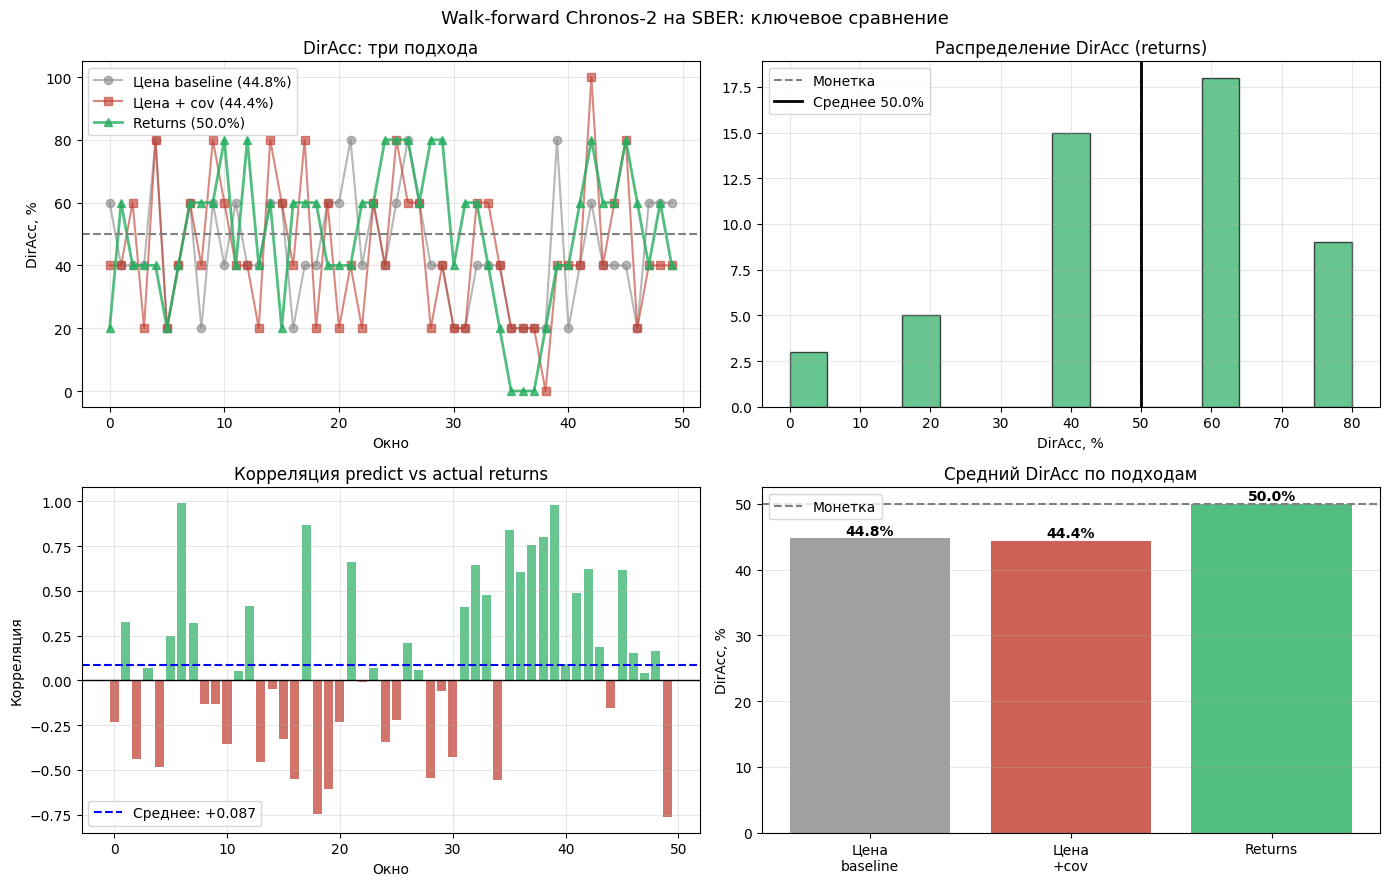

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. DirAcc сравнение всех трёх
axes[0, 0].plot(res_a["window"], res_a["dir_acc"], "o-", label=f"Цена baseline ({res_a['dir_acc'].mean():.1f}%)", color="#888", alpha=0.6)
axes[0, 0].plot(res_b["window"], res_b["dir_acc"], "s-", label=f"Цена + cov ({res_b['dir_acc'].mean():.1f}%)", color="#c0392b", alpha=0.6)
axes[0, 0].plot(res_r["window"], res_r["dir_acc"], "^-", label=f"Returns ({res_r['dir_acc'].mean():.1f}%)", color="#27ae60", alpha=0.8, lw=2)
axes[0, 0].axhline(50, color="gray", ls="--")
axes[0, 0].set_title("DirAcc: три подхода"); axes[0, 0].set_xlabel("Окно")
axes[0, 0].set_ylabel("DirAcc, %"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2. Распределение DirAcc для returns
axes[0, 1].hist(res_r["dir_acc"], bins=15, color="#27ae60", alpha=0.7, edgecolor="black")
axes[0, 1].axvline(50, color="gray", ls="--", label="Монетка")
axes[0, 1].axvline(res_r["dir_acc"].mean(), color="black", ls="-", lw=2, label=f"Среднее {res_r['dir_acc'].mean():.1f}%")
axes[0, 1].set_title("Распределение DirAcc (returns)")
axes[0, 1].set_xlabel("DirAcc, %"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# 3. Корреляция returns по окнам
axes[1, 0].bar(res_r["window"], res_r["return_corr"],
               color=["#27ae60" if c > 0 else "#c0392b" for c in res_r["return_corr"]], alpha=0.7)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].axhline(res_r["return_corr"].mean(), color="blue", ls="--",
                   label=f"Среднее: {res_r['return_corr'].mean():+.3f}")
axes[1, 0].set_title("Корреляция predict vs actual returns")
axes[1, 0].set_xlabel("Окно"); axes[1, 0].set_ylabel("Корреляция")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 4. Сравнение средних
methods = ["Цена\nbaseline", "Цена\n+cov", "Returns"]
dir_accs = [res_a["dir_acc"].mean(), res_b["dir_acc"].mean(), res_r["dir_acc"].mean()]
colors = ["#888", "#c0392b", "#27ae60"]
bars = axes[1, 1].bar(methods, dir_accs, color=colors, alpha=0.8)
axes[1, 1].axhline(50, color="gray", ls="--", label="Монетка")
for bar, val in zip(bars, dir_accs):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f"{val:.1f}%", ha="center", fontweight="bold")
axes[1, 1].set_title("Средний DirAcc по подходам")
axes[1, 1].set_ylabel("DirAcc, %"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3, axis="y")

plt.suptitle(f"Walk-forward Chronos-2 на SBER: ключевое сравнение", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

def make_features(prices, covariates_df, n_lags=10):
    """
    Строим фичи для CatBoost:
    - Лаги log-returns (1..N)
    - Скользящие статистики returns
    - Лаги ковариат (% изменения)
    - RSI, MACD-like, объём-нормализованный
    Возвращает DataFrame фич с тем же индексом что и prices.
    """
    log_ret = np.log(prices / prices.shift(1))
    feats = pd.DataFrame(index=prices.index)

    # Лаги returns
    for lag in range(1, n_lags + 1):
        feats[f"ret_lag_{lag}"] = log_ret.shift(lag)

    # Скользящие статистики
    feats["ret_ma_5"] = log_ret.shift(1).rolling(5).mean()
    feats["ret_ma_20"] = log_ret.shift(1).rolling(20).mean()
    feats["ret_std_5"] = log_ret.shift(1).rolling(5).std()
    feats["ret_std_20"] = log_ret.shift(1).rolling(20).std()

    # RSI-14 (упрощённый)
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    feats["rsi_14"] = 100 - (100 / (1 + rs))
    feats["rsi_14"] = feats["rsi_14"].shift(1)  # без leak

    # Momentum
    feats["mom_5"] = (prices.shift(1) / prices.shift(6) - 1)
    feats["mom_20"] = (prices.shift(1) / prices.shift(21) - 1)

    # Ковариаты — берём log-returns каждой ковариаты с лагом
    for col in covariates_df.columns:
        cov_log_ret = np.log(covariates_df[col] / covariates_df[col].shift(1))
        feats[f"{col}_ret_lag1"] = cov_log_ret.shift(1)
        feats[f"{col}_ret_lag5"] = cov_log_ret.shift(5)

    return feats

# Готовим фичи один раз на весь ряд
covariates_df = all_data[["sber_volume", "imoex", "moexog", "moexfn", "rgbi"]]
features = make_features(all_data["target"], covariates_df, n_lags=10)
target_returns = np.log(all_data["target"] / all_data["target"].shift(1))

# Объединяем — оставляем только строки где все фичи есть
ml_data = pd.concat([target_returns.rename("y"), features], axis=1).dropna()
print(f"Готовый датасет для CatBoost: {len(ml_data)} строк, {ml_data.shape[1]-1} фич")
print(f"Фичи: {list(features.columns)[:5]}... (всего {features.shape[1]})")
ml_data.head()

Готовый датасет для CatBoost: 499 строк, 27 фич
Фичи: ['ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5']... (всего 27)


,y,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ret_lag_6,ret_lag_7,ret_lag_8,ret_lag_9,...,sber_volume_ret_lag1,sber_volume_ret_lag5,imoex_ret_lag1,imoex_ret_lag5,moexog_ret_lag1,moexog_ret_lag5,moexfn_ret_lag1,moexfn_ret_lag5,rgbi_ret_lag1,rgbi_ret_lag5
begin,,,,,,,,,,,,,,,,,,,,,
2023-02-01,0.001391,0.030119,0.001174,0.005236,-0.002687,0.000982,-0.005487,0.013907,0.013568,-0.014162,...,0.917926,-0.596154,0.009567,-0.001197,0.001929,-0.001469,0.023353,-0.005432,-0.000307,0.000000
2023-02-02,0.007302,0.001391,0.030119,0.001174,0.005236,-0.002687,0.000982,-0.005487,0.013907,0.013568,...,-0.160626,0.048083,0.002042,-0.001489,-0.000054,-0.003471,-0.005061,-0.001040,0.000000,0.000769
2023-02-03,0.011288,0.007302,0.001391,0.030119,0.001174,0.005236,-0.002687,0.000982,-0.005487,0.013907,...,-0.208169,-0.288013,0.005986,0.010298,0.000268,0.013626,0.010194,0.005803,0.000538,0.000461
2023-02-06,0.035515,0.011288,0.007302,0.001391,0.030119,0.001174,0.005236,-0.002687,0.000982,-0.005487,...,0.168233,-0.092616,0.002119,0.006855,0.002031,0.003620,-0.000939,0.006207,-0.001460,0.000154
2023-02-07,-0.010226,0.035515,0.011288,0.007302,0.001391,0.030119,0.001174,0.005236,-0.002687,0.000982,...,0.334835,0.917926,0.010649,0.009567,0.008113,0.001929,0.020299,0.023353,-0.000385,-0.000307


In [ ]:
results_catboost = []

for i in tqdm(range(N_WINDOWS), desc="Walk-forward CatBoost"):
    end_idx = len(ml_data) - i
    test_start = end_idx - HORIZON
    ctx_start = test_start - CONTEXT_LEN
    if ctx_start < 0:
        break

    train = ml_data.iloc[ctx_start:test_start]
    test = ml_data.iloc[test_start:end_idx]

    X_train, y_train = train.drop(columns="y"), train["y"]
    X_test, y_test = test.drop(columns="y"), test["y"]

    # Цены для метрик
    last_price = all_data["target"].loc[train.index[-1]]
    test_prices = all_data["target"].loc[test.index].values

    model = CatBoostRegressor(
        iterations=300,
        learning_rate=0.03,
        depth=4,
        loss_function="RMSE",
        verbose=False,
        random_seed=42,
    )
    model.fit(X_train, y_train)
    y_pred_returns = model.predict(X_test)
    y_true_returns = y_test.values

    # Реконструируем цены
    y_pred_prices = last_price * np.exp(np.cumsum(y_pred_returns))

    # Метрики (идентичные returns-эксперименту)
    mae = np.mean(np.abs(test_prices - y_pred_prices))
    mape = np.mean(np.abs((test_prices - y_pred_prices) / test_prices)) * 100
    dir_acc = (np.sign(y_pred_returns) == np.sign(y_true_returns)).mean() * 100
    corr = np.corrcoef(y_pred_returns, y_true_returns)[0, 1] if len(y_pred_returns) > 1 else np.nan

    results_catboost.append({
        "window": i, "mae": mae, "mape": mape,
        "dir_acc": dir_acc, "return_corr": corr,
    })

res_cb = pd.DataFrame(results_catboost)
print(f"\nГотово: {len(res_cb)} окон")

Walk-forward CatBoost: 100%|██████████| 50/50 [01:17<00:00,  1.55s/it]


Готово: 50 окон


In [ ]:
print("=" * 75)
print(f"Chronos-2 (returns) vs CatBoost (returns) на 50 окнах SBER")
print("=" * 75)
print(f"\n{'Метрика':<20} {'Chronos-2':>12} {'CatBoost':>12} {'Победитель':>15}")
print("-" * 75)

for col, lower_better in [("mae", True), ("mape", True), ("dir_acc", False), ("return_corr", False)]:
    c, b = res_r[col].mean(), res_cb[col].mean()
    if lower_better:
        winner = "Chronos-2" if c < b else "CatBoost"
    else:
        winner = "Chronos-2" if c > b else "CatBoost"
    print(f"{col:<20} {c:>12.3f} {b:>12.3f} {winner:>15}")

print(f"\nDirAcc распределения:")
print(f"  Chronos-2: medianа {res_r['dir_acc'].median():.0f}%, окон >50%: {(res_r['dir_acc']>50).mean()*100:.0f}%")
print(f"  CatBoost:  медиана {res_cb['dir_acc'].median():.0f}%, окон >50%: {(res_cb['dir_acc']>50).mean()*100:.0f}%")
print(f"\nКорреляция returns:")
print(f"  Chronos-2: {res_r['return_corr'].mean():+.3f}")
print(f"  CatBoost:  {res_cb['return_corr'].mean():+.3f}")

Chronos-2 (returns) vs CatBoost (returns) на 50 окнах SBER

Метрика                 Chronos-2     CatBoost      Победитель
---------------------------------------------------------------------------
mae                         8.287        8.314       Chronos-2
mape                        3.354        3.357       Chronos-2
dir_acc                    50.000       42.800       Chronos-2
return_corr                 0.087       -0.118       Chronos-2

DirAcc распределения:
  Chronos-2: medianа 60%, окон >50%: 54%
  CatBoost:  медиана 40%, окон >50%: 34%

Корреляция returns:
  Chronos-2: +0.087
  CatBoost:  -0.118


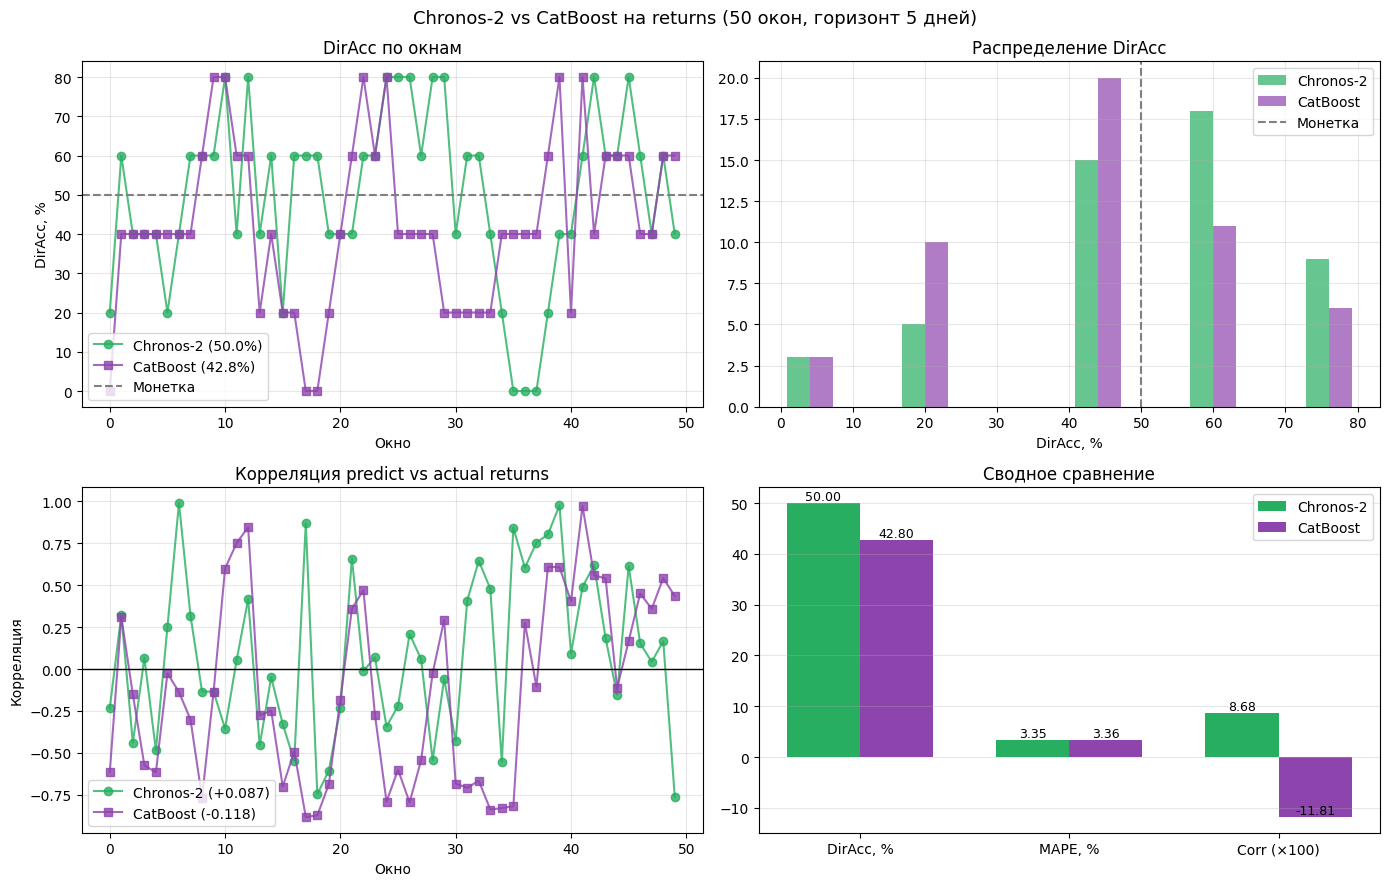

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. DirAcc по окнам
axes[0, 0].plot(res_r["window"], res_r["dir_acc"], "o-", label=f"Chronos-2 ({res_r['dir_acc'].mean():.1f}%)", color="#27ae60", alpha=0.8)
axes[0, 0].plot(res_cb["window"], res_cb["dir_acc"], "s-", label=f"CatBoost ({res_cb['dir_acc'].mean():.1f}%)", color="#8e44ad", alpha=0.8)
axes[0, 0].axhline(50, color="gray", ls="--", label="Монетка")
axes[0, 0].set_title("DirAcc по окнам")
axes[0, 0].set_xlabel("Окно"); axes[0, 0].set_ylabel("DirAcc, %")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2. Распределение DirAcc
axes[0, 1].hist([res_r["dir_acc"], res_cb["dir_acc"]], bins=10,
                label=["Chronos-2", "CatBoost"], color=["#27ae60", "#8e44ad"], alpha=0.7)
axes[0, 1].axvline(50, color="gray", ls="--", label="Монетка")
axes[0, 1].set_title("Распределение DirAcc")
axes[0, 1].set_xlabel("DirAcc, %"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# 3. Корреляция returns
axes[1, 0].plot(res_r["window"], res_r["return_corr"], "o-", label=f"Chronos-2 ({res_r['return_corr'].mean():+.3f})", color="#27ae60", alpha=0.8)
axes[1, 0].plot(res_cb["window"], res_cb["return_corr"], "s-", label=f"CatBoost ({res_cb['return_corr'].mean():+.3f})", color="#8e44ad", alpha=0.8)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_title("Корреляция predict vs actual returns")
axes[1, 0].set_xlabel("Окно"); axes[1, 0].set_ylabel("Корреляция")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 4. Bar сравнения средних
metrics = ["DirAcc, %", "MAPE, %", "Corr (×100)"]
chronos_vals = [res_r["dir_acc"].mean(), res_r["mape"].mean(), res_r["return_corr"].mean()*100]
catboost_vals = [res_cb["dir_acc"].mean(), res_cb["mape"].mean(), res_cb["return_corr"].mean()*100]
x = np.arange(len(metrics))
w = 0.35
axes[1, 1].bar(x - w/2, chronos_vals, w, label="Chronos-2", color="#27ae60")
axes[1, 1].bar(x + w/2, catboost_vals, w, label="CatBoost", color="#8e44ad")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_title("Сводное сравнение")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3, axis="y")
for i, (c, b) in enumerate(zip(chronos_vals, catboost_vals)):
    axes[1, 1].text(i - w/2, c + 0.5, f"{c:.2f}", ha="center", fontsize=9)
    axes[1, 1].text(i + w/2, b + 0.5, f"{b:.2f}", ha="center", fontsize=9)

plt.suptitle(f"Chronos-2 vs CatBoost на returns ({N_WINDOWS} окон, горизонт {HORIZON} дней)", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
TICKERS = ["SBER", "GAZP", "LKOH", "ROSN"]

def run_chronos_walkforward(ticker, date_from, date_till, n_windows=50, horizon=5, context_len=250):
    """Полный цикл: тянем данные → returns → walk-forward → метрики."""

    # 1. Тянем данные
    data = fetch_moex_candles(ticker, date_from, date_till, INTERVAL)
    if len(data) < context_len + horizon + n_windows:
        print(f"  [{ticker}] недостаточно данных: {len(data)}")
        return None

    # 2. Приводим к B-частоте и считаем log-returns
    prices = (
        data.set_index("begin")["close"]
        .astype(float)
        .asfreq("B")
        .ffill()
    )
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # 3. Walk-forward
    rows = []
    for i in range(n_windows):
        end_idx = len(log_returns) - i
        test_start = end_idx - horizon
        ctx_start = test_start - context_len
        if ctx_start < 0:
            break

        ctx_returns = log_returns.iloc[ctx_start:test_start]
        test_returns = log_returns.iloc[test_start:end_idx]
        last_price = prices.loc[ctx_returns.index[-1]]
        test_prices = prices.loc[test_returns.index].values

        ctx_input = pd.DataFrame({
            "id": ticker,
            "timestamp": ctx_returns.index,
            "target": ctx_returns.values,
        })

        pred = pipeline.predict_df(
            ctx_input,
            prediction_length=horizon,
            quantile_levels=QUANTILES,
            id_column="id",
            timestamp_column="timestamp",
            target="target",
        )
        y_pred_returns = pred["0.5"].values
        y_true_returns = test_returns.values
        y_pred_prices = last_price * np.exp(np.cumsum(y_pred_returns))

        mae = np.mean(np.abs(test_prices - y_pred_prices))
        mape = np.mean(np.abs((test_prices - y_pred_prices) / test_prices)) * 100
        dir_acc = (np.sign(y_pred_returns) == np.sign(y_true_returns)).mean() * 100
        corr = np.corrcoef(y_pred_returns, y_true_returns)[0, 1] if len(y_pred_returns) > 1 else np.nan

        rows.append({
            "ticker": ticker, "window": i,
            "mae": mae, "mape": mape, "dir_acc": dir_acc, "return_corr": corr,
        })

    return pd.DataFrame(rows)


# Прогон по всем тикерам
all_results = {}
for tic in TICKERS:
    print(f"\n>>> {tic}")
    res = run_chronos_walkforward(tic, DATE_FROM, DATE_TILL)
    if res is not None:
        all_results[tic] = res
        print(f"   DirAcc={res['dir_acc'].mean():.1f}%  Corr={res['return_corr'].mean():+.3f}  MAPE={res['mape'].mean():.2f}%")


>>> SBER
   DirAcc=50.0%  Corr=+0.087  MAPE=3.35%

>>> GAZP
   DirAcc=53.2%  Corr=-0.003  MAPE=4.01%

>>> LKOH
   DirAcc=38.0%  Corr=-0.004  MAPE=2.07%

>>> ROSN
   DirAcc=43.2%  Corr=+0.162  MAPE=3.49%


In [ ]:
print("=" * 80)
print(f"Chronos-2 на returns: сводка по {len(all_results)} тикерам ({HORIZON} дней, {N_WINDOWS} окон)")
print("=" * 80)
print(f"\n{'Тикер':<8} {'DirAcc avg':>12} {'DirAcc med':>12} {'Corr':>10} {'MAPE':>10} {'>50%':>8} {'>60%':>8}")
print("-" * 80)

summary = []
for tic, res in all_results.items():
    row = {
        "ticker": tic,
        "dir_acc_mean": res["dir_acc"].mean(),
        "dir_acc_median": res["dir_acc"].median(),
        "corr": res["return_corr"].mean(),
        "mape": res["mape"].mean(),
        "share_above_50": (res["dir_acc"] > 50).mean() * 100,
        "share_above_60": (res["dir_acc"] > 60).mean() * 100,
    }
    summary.append(row)
    print(f"{tic:<8} {row['dir_acc_mean']:>12.1f} {row['dir_acc_median']:>12.1f} "
          f"{row['corr']:>+10.3f} {row['mape']:>10.2f} "
          f"{row['share_above_50']:>7.0f}% {row['share_above_60']:>7.0f}%")

summary_df = pd.DataFrame(summary)

# Среднее по всем тикерам
print("-" * 80)
print(f"{'СРЕДНЕЕ':<8} {summary_df['dir_acc_mean'].mean():>12.1f} {summary_df['dir_acc_median'].mean():>12.1f} "
      f"{summary_df['corr'].mean():>+10.3f} {summary_df['mape'].mean():>10.2f} "
      f"{summary_df['share_above_50'].mean():>7.0f}% {summary_df['share_above_60'].mean():>7.0f}%")

Chronos-2 на returns: сводка по 4 тикерам (5 дней, 50 окон)

Тикер      DirAcc avg   DirAcc med       Corr       MAPE     >50%     >60%
--------------------------------------------------------------------------------
SBER             50.0         60.0     +0.087       3.35      54%      18%
GAZP             53.2         60.0     -0.003       4.01      62%      30%
LKOH             38.0         40.0     -0.004       2.07      26%       6%
ROSN             43.2         40.0     +0.162       3.49      46%      16%
--------------------------------------------------------------------------------
СРЕДНЕЕ          46.1         50.0     +0.061       3.23      47%      18%


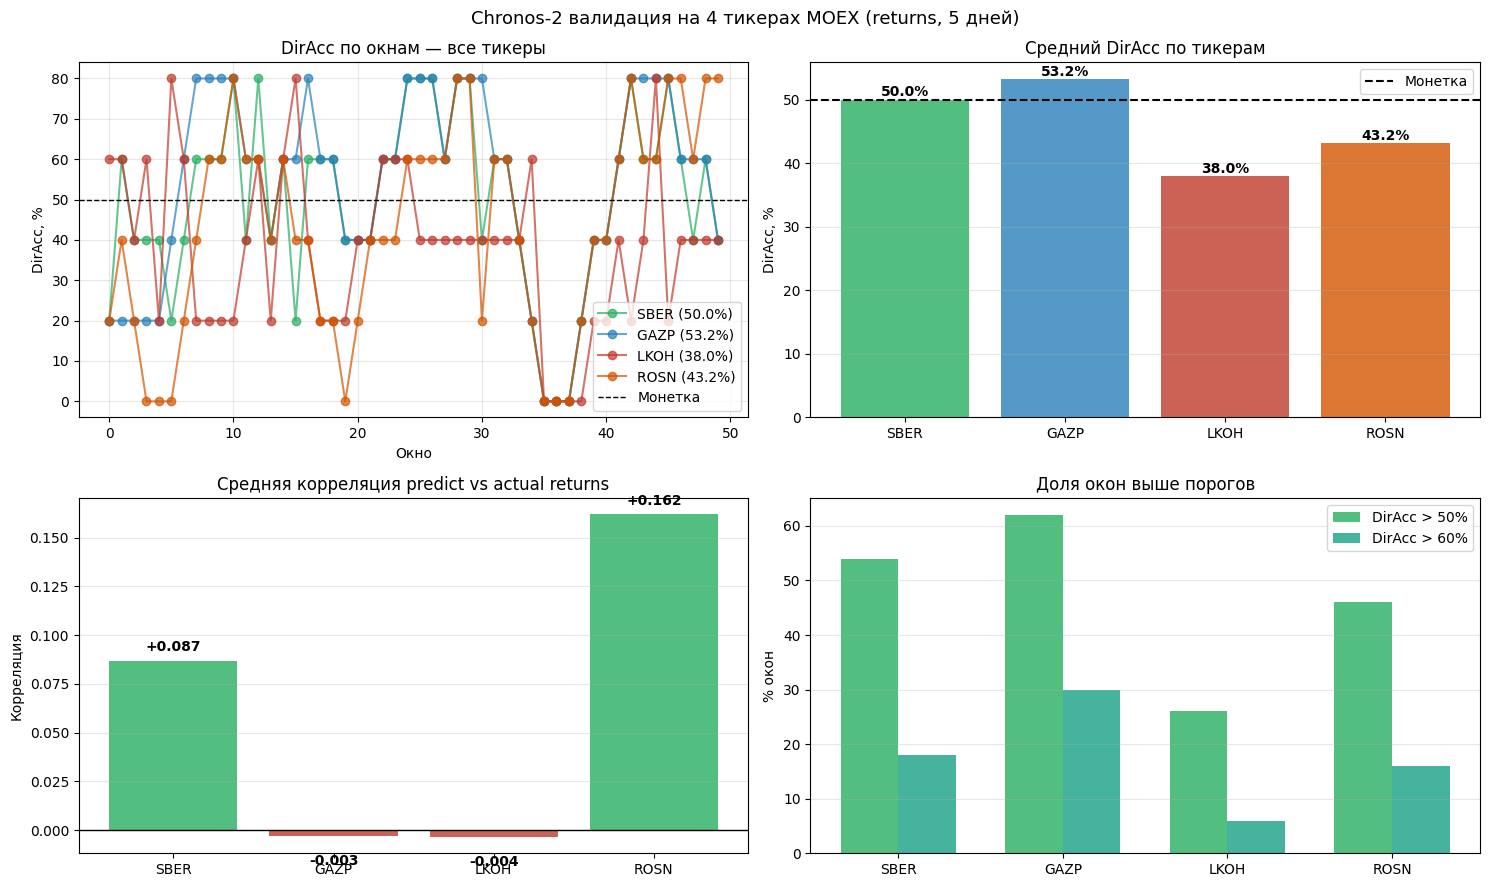

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
colors = {"SBER": "#27ae60", "GAZP": "#2980b9", "LKOH": "#c0392b", "ROSN": "#d35400"}

# 1. DirAcc по окнам для каждого тикера
for tic, res in all_results.items():
    axes[0, 0].plot(res["window"], res["dir_acc"], "o-",
                    label=f"{tic} ({res['dir_acc'].mean():.1f}%)",
                    color=colors.get(tic, "gray"), alpha=0.7)
axes[0, 0].axhline(50, color="black", ls="--", lw=1, label="Монетка")
axes[0, 0].set_title("DirAcc по окнам — все тикеры")
axes[0, 0].set_xlabel("Окно"); axes[0, 0].set_ylabel("DirAcc, %")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2. Bar chart средних DirAcc
tickers = list(all_results.keys())
dir_accs = [all_results[t]["dir_acc"].mean() for t in tickers]
bars = axes[0, 1].bar(tickers, dir_accs, color=[colors.get(t, "gray") for t in tickers], alpha=0.8)
axes[0, 1].axhline(50, color="black", ls="--", label="Монетка")
for bar, val in zip(bars, dir_accs):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f"{val:.1f}%", ha="center", fontweight="bold")
axes[0, 1].set_title("Средний DirAcc по тикерам")
axes[0, 1].set_ylabel("DirAcc, %"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3, axis="y")

# 3. Корреляция returns
corrs = [all_results[t]["return_corr"].mean() for t in tickers]
bar_colors = ["#27ae60" if c > 0 else "#c0392b" for c in corrs]
bars = axes[1, 0].bar(tickers, corrs, color=bar_colors, alpha=0.8)
axes[1, 0].axhline(0, color="black", lw=1)
for bar, val in zip(bars, corrs):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    val + (0.005 if val >= 0 else -0.015),
                    f"{val:+.3f}", ha="center", fontweight="bold")
axes[1, 0].set_title("Средняя корреляция predict vs actual returns")
axes[1, 0].set_ylabel("Корреляция"); axes[1, 0].grid(alpha=0.3, axis="y")

# 4. Доля «хороших» окон
share_50 = [(all_results[t]["dir_acc"] > 50).mean() * 100 for t in tickers]
share_60 = [(all_results[t]["dir_acc"] > 60).mean() * 100 for t in tickers]
x = np.arange(len(tickers))
w = 0.35
axes[1, 1].bar(x - w/2, share_50, w, label="DirAcc > 50%", color="#27ae60", alpha=0.8)
axes[1, 1].bar(x + w/2, share_60, w, label="DirAcc > 60%", color="#16a085", alpha=0.8)
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(tickers)
axes[1, 1].set_title("Доля окон выше порогов")
axes[1, 1].set_ylabel("% окон"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3, axis="y")

plt.suptitle(f"Chronos-2 валидация на {len(tickers)} тикерах MOEX (returns, {HORIZON} дней)", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
TICKERS = ["SBER", "GAZP", "LKOH", "ROSN"]
HORIZON = 5
CONTEXT_LEN = 250

prod_results = []

for tic in TICKERS:
    print(f"\n>>> {tic}")

    # 1. Тянем данные
    data = fetch_moex_candles(tic, DATE_FROM, DATE_TILL, INTERVAL)
    prices = (
        data.set_index("begin")["close"]
        .astype(float)
        .asfreq("B")
        .ffill()
    )
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # 2. Делим: всё кроме последних 5 дней — контекст, последние 5 — "будущее"
    ctx_returns = log_returns.iloc[-(CONTEXT_LEN + HORIZON):-HORIZON]
    test_returns = log_returns.iloc[-HORIZON:]

    last_price = prices.loc[ctx_returns.index[-1]]
    test_prices = prices.loc[test_returns.index].values

    # 3. Прогноз
    ctx_input = pd.DataFrame({
        "id": tic,
        "timestamp": ctx_returns.index,
        "target": ctx_returns.values,
    })
    pred = pipeline.predict_df(
        ctx_input,
        prediction_length=HORIZON,
        quantile_levels=QUANTILES,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )

    y_pred_returns = pred["0.5"].values
    y_true_returns = test_returns.values
    y_pred_prices = last_price * np.exp(np.cumsum(y_pred_returns))

    # 4. Метрики
    mae = np.mean(np.abs(test_prices - y_pred_prices))
    mape = np.mean(np.abs((test_prices - y_pred_prices) / test_prices)) * 100
    dir_acc = (np.sign(y_pred_returns) == np.sign(y_true_returns)).mean() * 100

    # Кумулятивный прогноз vs факт за горизонт
    cum_pred = np.exp(y_pred_returns.sum()) - 1   # суммарная доходность по прогнозу, %
    cum_true = np.exp(y_true_returns.sum()) - 1   # фактическая суммарная доходность

    # 5. Торговое решение: модель говорит лонг или шорт?
    # На основе суммарного прогноза returns за горизонт
    direction = "LONG" if cum_pred > 0 else "SHORT" if cum_pred < 0 else "HOLD"
    # Сработала ли сделка? Сравниваем направление прогноза с реальным
    correct_direction = np.sign(cum_pred) == np.sign(cum_true)

    # Ширина квантильного коридора (среднее по горизонту) — оценка уверенности
    coridor_width = (pred["0.9"].values - pred["0.1"].values).mean()
    confidence = "HIGH" if coridor_width < 0.02 else "MEDIUM" if coridor_width < 0.04 else "LOW"

    print(f"   Прогноз returns за {HORIZON} дн: {cum_pred*100:+.2f}% ({direction})")
    print(f"   Факт:                          {cum_true*100:+.2f}%")
    print(f"   Угадали направление:           {'✓' if correct_direction else '✗'}")
    print(f"   DirAcc по дням:                {dir_acc:.0f}%")
    print(f"   MAPE по ценам:                 {mape:.2f}%")
    print(f"   Уверенность:                   {confidence} (коридор {coridor_width*100:.2f}%)")

    prod_results.append({
        "ticker": tic,
        "pred_return_%": cum_pred * 100,
        "actual_return_%": cum_true * 100,
        "direction": direction,
        "correct_dir": correct_direction,
        "dir_acc_daily": dir_acc,
        "mape": mape,
        "confidence": confidence,
        "coridor_width_%": coridor_width * 100,
        "test_period": f"{test_returns.index[0].date()} → {test_returns.index[-1].date()}",
    })

prod_df = pd.DataFrame(prod_results)


>>> SBER
   Прогноз returns за 5 дн: -0.02% (SHORT)
   Факт:                          +5.49%
   Угадали направление:           ✗
   DirAcc по дням:                20%
   MAPE по ценам:                 2.40%
   Уверенность:                   LOW (коридор 6.13%)

>>> GAZP
   Прогноз returns за 5 дн: -0.79% (SHORT)
   Факт:                          +11.16%
   Угадали направление:           ✗
   DirAcc по дням:                20%
   MAPE по ценам:                 6.44%
   Уверенность:                   LOW (коридор 6.49%)

>>> LKOH
   Прогноз returns за 5 дн: +0.17% (LONG)
   Факт:                          +4.57%
   Угадали направление:           ✓
   DirAcc по дням:                60%
   MAPE по ценам:                 1.67%
   Уверенность:                   LOW (коридор 5.01%)

>>> ROSN
   Прогноз returns за 5 дн: -0.12% (SHORT)
   Факт:                          +6.34%
   Угадали направление:           ✗
   DirAcc по дням:                20%
   MAPE по ценам:                 2.79%
   Уве

In [ ]:
print("=" * 95)
print(f"PROD-симуляция: один свежий прогноз по 4 тикерам (горизонт {HORIZON} дней)")
print(f"Период теста: {prod_df['test_period'].iloc[0]}")
print("=" * 95)
print()
print(prod_df[["ticker", "pred_return_%", "actual_return_%", "direction",
               "correct_dir", "confidence", "mape"]].to_string(index=False))

correct = prod_df["correct_dir"].sum()
total = len(prod_df)
print(f"\nИтог: угадано направлений {correct}/{total} ({correct/total*100:.0f}%)")

# Симуляция P&L: если бы мы открыли сделку по каждому "не HOLD" с равной долей
trades = prod_df[prod_df["direction"] != "HOLD"].copy()
trades["pnl_%"] = trades.apply(
    lambda r: r["actual_return_%"] if r["direction"] == "LONG" else -r["actual_return_%"],
    axis=1
)
print(f"\nСимуляция P&L (равные доли по {len(trades)} сделкам):")
print(trades[["ticker", "direction", "actual_return_%", "pnl_%"]].to_string(index=False))
print(f"\nСуммарный P&L: {trades['pnl_%'].sum():+.2f}%  (среднее: {trades['pnl_%'].mean():+.2f}% на сделку)")

PROD-симуляция: один свежий прогноз по 4 тикерам (горизонт 5 дней)
Период теста: 2024-12-24 → 2024-12-30

ticker  pred_return_%  actual_return_% direction  correct_dir confidence     mape
  SBER      -0.020963         5.485089     SHORT        False        LOW 2.400084
  GAZP      -0.790554        11.164927     SHORT        False        LOW 6.442639
  LKOH       0.165415         4.567134      LONG         True        LOW 1.666851
  ROSN      -0.115299         6.343218     SHORT        False        LOW 2.791897

Итог: угадано направлений 1/4 (25%)

Симуляция P&L (равные доли по 4 сделкам):
ticker direction  actual_return_%      pnl_%
  SBER     SHORT         5.485089  -5.485089
  GAZP     SHORT        11.164927 -11.164927
  LKOH      LONG         4.567134   4.567134
  ROSN     SHORT         6.343218  -6.343218

Суммарный P&L: -18.43%  (среднее: -4.61% на сделку)


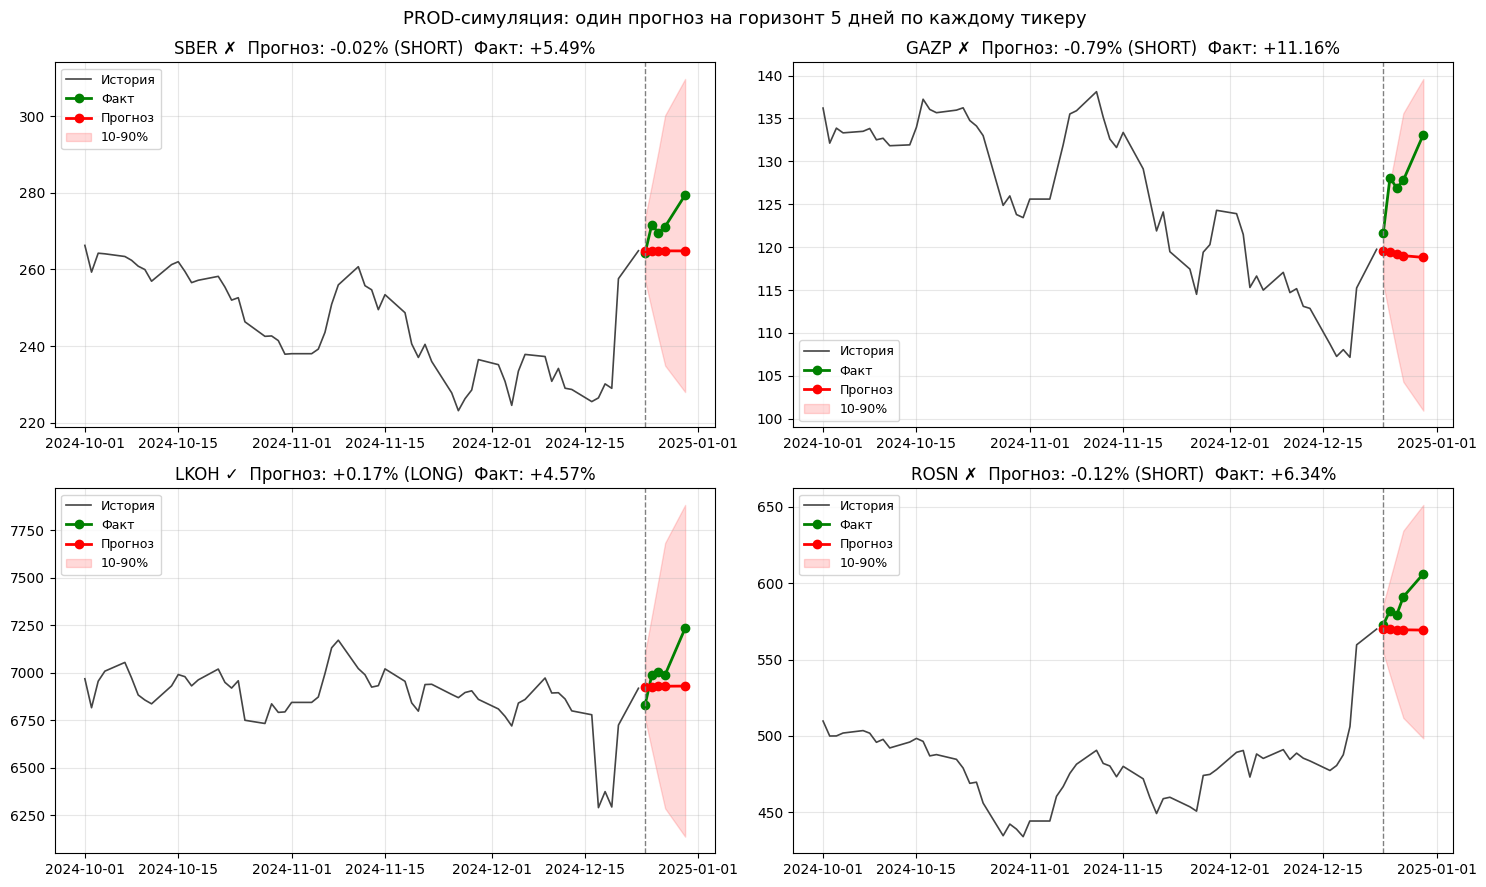

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for idx, (ax, tic) in enumerate(zip(axes.flat, TICKERS)):
    data = fetch_moex_candles(tic, DATE_FROM, DATE_TILL, INTERVAL)
    prices = data.set_index("begin")["close"].astype(float).asfreq("B").ffill()
    log_returns = np.log(prices / prices.shift(1)).dropna()

    ctx_returns = log_returns.iloc[-(CONTEXT_LEN + HORIZON):-HORIZON]
    test_returns = log_returns.iloc[-HORIZON:]
    last_price = prices.loc[ctx_returns.index[-1]]
    test_prices = prices.loc[test_returns.index].values

    ctx_input = pd.DataFrame({
        "id": tic, "timestamp": ctx_returns.index, "target": ctx_returns.values,
    })
    pred = pipeline.predict_df(
        ctx_input, prediction_length=HORIZON, quantile_levels=QUANTILES,
        id_column="id", timestamp_column="timestamp", target="target",
    )

    y_pred = last_price * np.exp(np.cumsum(pred["0.5"].values))
    y_lo = last_price * np.exp(np.cumsum(pred["0.1"].values))
    y_hi = last_price * np.exp(np.cumsum(pred["0.9"].values))

    hist_prices = prices.loc[ctx_returns.index].iloc[-60:]
    ax.plot(hist_prices.index, hist_prices.values, color="#444", lw=1.2, label="История")
    ax.plot(test_returns.index, test_prices, "go-", lw=2, label="Факт", markersize=6)
    ax.plot(test_returns.index, y_pred, "ro-", lw=2, label="Прогноз", markersize=6)
    ax.fill_between(test_returns.index, y_lo, y_hi, color="red", alpha=0.15, label="10-90%")
    ax.axvline(test_returns.index[0], color="gray", ls="--", lw=1)

    row = prod_df[prod_df["ticker"] == tic].iloc[0]
    mark = "✓" if row["correct_dir"] else "✗"
    ax.set_title(
        f"{tic} {mark}  Прогноз: {row['pred_return_%']:+.2f}% ({row['direction']})  "
        f"Факт: {row['actual_return_%']:+.2f}%"
    )
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle(f"PROD-симуляция: один прогноз на горизонт {HORIZON} дней по каждому тикеру", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
TICKERS = ["SBER", "GAZP", "LKOH", "ROSN"]
HORIZON = 5
CONTEXT_LEN = 250
N_DATES = 10

# Кэшируем все цены один раз чтобы не дёргать MOEX 40 раз
print("Кэшируем данные по тикерам...")
ticker_data = {}
for tic in TICKERS:
    data = fetch_moex_candles(tic, DATE_FROM, DATE_TILL, INTERVAL)
    prices = (
        data.set_index("begin")["close"]
        .astype(float)
        .asfreq("B")
        .ffill()
    )
    log_returns = np.log(prices / prices.shift(1)).dropna()
    ticker_data[tic] = {"prices": prices, "log_returns": log_returns}
    print(f"  {tic}: {len(log_returns)} точек")

# Берём 10 дат равномерно по последним N точкам ряда (минимум CONTEXT_LEN с начала)
ref_returns = ticker_data["SBER"]["log_returns"]
available_range = len(ref_returns) - CONTEXT_LEN - HORIZON
date_indices = np.linspace(CONTEXT_LEN, len(ref_returns) - HORIZON, N_DATES, dtype=int)
test_dates = [ref_returns.index[i] for i in date_indices]
print(f"\nВыбраны {len(test_dates)} тестовых дат:")
for d in test_dates:
    print(f"  {d.date()}")

Кэшируем данные по тикерам...
  SBER: 519 точек
  GAZP: 519 точек
  LKOH: 519 точек
  ROSN: 519 точек

Выбраны 10 тестовых дат:
  2023-12-20
  2024-01-30
  2024-03-11
  2024-04-22
  2024-05-31
  2024-07-11
  2024-08-22
  2024-10-02
  2024-11-12
  2024-12-24


In [ ]:
prod_log = []

for date_idx, test_date in enumerate(tqdm(test_dates, desc="Даты")):
    for tic in TICKERS:
        prices = ticker_data[tic]["prices"]
        log_returns = ticker_data[tic]["log_returns"]

        # Находим позицию test_date в ряде returns
        if test_date not in log_returns.index:
            continue
        pos = log_returns.index.get_loc(test_date)

        if pos < CONTEXT_LEN or pos + HORIZON > len(log_returns):
            continue

        ctx_returns = log_returns.iloc[pos - CONTEXT_LEN:pos]
        test_returns = log_returns.iloc[pos:pos + HORIZON]
        last_price = prices.loc[ctx_returns.index[-1]]

        ctx_input = pd.DataFrame({
            "id": tic,
            "timestamp": ctx_returns.index,
            "target": ctx_returns.values,
        })

        pred = pipeline.predict_df(
            ctx_input,
            prediction_length=HORIZON,
            quantile_levels=QUANTILES,
            id_column="id",
            timestamp_column="timestamp",
            target="target",
        )

        y_pred_returns = pred["0.5"].values
        y_true_returns = test_returns.values

        # Кумулятивные returns за горизонт
        cum_pred = np.exp(y_pred_returns.sum()) - 1
        cum_true = np.exp(y_true_returns.sum()) - 1

        direction = "LONG" if cum_pred > 0 else "SHORT" if cum_pred < 0 else "HOLD"
        correct_dir = np.sign(cum_pred) == np.sign(cum_true)

        # P&L: лонг даёт +cum_true, шорт даёт -cum_true
        if direction == "LONG":
            pnl = cum_true
        elif direction == "SHORT":
            pnl = -cum_true
        else:
            pnl = 0

        # Uncertainty: средняя ширина квантильного коридора
        coridor_width = (pred["0.9"].values - pred["0.1"].values).mean()

        prod_log.append({
            "date": test_date.date(),
            "ticker": tic,
            "pred_return_%": cum_pred * 100,
            "actual_return_%": cum_true * 100,
            "direction": direction,
            "correct_dir": correct_dir,
            "pnl_%": pnl * 100,
            "coridor_width_%": coridor_width * 100,
        })

prod_log_df = pd.DataFrame(prod_log)
print(f"\nПрогнано: {len(prod_log_df)} сделок ({prod_log_df['ticker'].nunique()} тикеров × {prod_log_df['date'].nunique()} дат)")

Даты: 100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


Прогнано: 40 сделок (4 тикеров × 10 дат)


In [ ]:
print("=" * 75)
print(f"PROD-симуляция: {len(prod_log_df)} сделок (4 тикера × {N_DATES} дат)")
print("=" * 75)

# Общая статистика
total_trades = len(prod_log_df)
correct_trades = prod_log_df["correct_dir"].sum()
total_pnl = prod_log_df["pnl_%"].sum()
avg_pnl = prod_log_df["pnl_%"].mean()
median_pnl = prod_log_df["pnl_%"].median()
winrate = correct_trades / total_trades * 100

print(f"\nWinrate (угадали направление): {correct_trades}/{total_trades} = {winrate:.1f}%")
print(f"Суммарный P&L:                 {total_pnl:+.2f}%")
print(f"Средний P&L на сделку:         {avg_pnl:+.2f}%")
print(f"Медианный P&L на сделку:       {median_pnl:+.2f}%")
print(f"Лучшая сделка:                 {prod_log_df['pnl_%'].max():+.2f}%")
print(f"Худшая сделка:                 {prod_log_df['pnl_%'].min():+.2f}%")
print(f"% прибыльных сделок:           {(prod_log_df['pnl_%'] > 0).mean() * 100:.0f}%")

# По тикерам
print(f"\n{'Тикер':<8} {'Winrate':>10} {'Сум P&L':>12} {'Ср P&L':>10}")
print("-" * 45)
for tic in TICKERS:
    sub = prod_log_df[prod_log_df["ticker"] == tic]
    print(f"{tic:<8} {sub['correct_dir'].mean()*100:>9.0f}% "
          f"{sub['pnl_%'].sum():>+11.2f}% {sub['pnl_%'].mean():>+9.2f}%")

# По датам
print(f"\nP&L по датам (сумма по 4 тикерам):")
date_summary = prod_log_df.groupby("date").agg(
    pnl=("pnl_%", "sum"), winrate=("correct_dir", "mean")
).reset_index()
date_summary["winrate"] *= 100
for _, row in date_summary.iterrows():
    bar = "█" * int(abs(row["pnl"]))
    sign = "+" if row["pnl"] >= 0 else "-"
    print(f"  {row['date']}  P&L={row['pnl']:+6.2f}%  WR={row['winrate']:>3.0f}%  {sign}{bar}")

PROD-симуляция: 40 сделок (4 тикера × 10 дат)

Winrate (угадали направление): 18/40 = 45.0%
Суммарный P&L:                 -28.46%
Средний P&L на сделку:         -0.71%
Медианный P&L на сделку:       -0.38%
Лучшая сделка:                 +6.52%
Худшая сделка:                 -11.16%
% прибыльных сделок:           45%

Тикер       Winrate      Сум P&L     Ср P&L
---------------------------------------------
SBER            30%      -21.54%     -2.15%
GAZP            60%       -3.76%     -0.38%
LKOH            40%       +1.34%     +0.13%
ROSN            50%       -4.50%     -0.45%

P&L по датам (сумма по 4 тикерам):
  2023-12-20  P&L= +8.00%  WR=100%  +███████
  2024-01-30  P&L= +6.17%  WR= 75%  +██████
  2024-03-11  P&L= -3.33%  WR= 25%  -███
  2024-04-22  P&L= +5.15%  WR=100%  +█████
  2024-05-31  P&L= -2.31%  WR= 25%  -██
  2024-07-11  P&L=-19.20%  WR=  0%  -███████████████████
  2024-08-22  P&L= -3.45%  WR= 25%  -███
  2024-10-02  P&L= +1.78%  WR= 50%  +█
  2024-11-12  P&L= -2.85%  W

In [ ]:
# Делим сделки на 3 группы по ширине коридора
prod_log_df["confidence"] = pd.qcut(
    prod_log_df["coridor_width_%"], q=3, labels=["HIGH", "MED", "LOW"]
)

print("\n=== Связь uncertainty с точностью ===")
print(f"\n{'Группа':<10} {'Сделок':>8} {'Winrate':>10} {'Ср P&L':>10} {'Сум P&L':>12}")
print("-" * 55)
for conf in ["HIGH", "MED", "LOW"]:
    sub = prod_log_df[prod_log_df["confidence"] == conf]
    print(f"{conf:<10} {len(sub):>8} {sub['correct_dir'].mean()*100:>9.1f}% "
          f"{sub['pnl_%'].mean():>+9.2f}% {sub['pnl_%'].sum():>+11.2f}%")

print("\nГипотеза: HIGH confidence → лучше Winrate и P&L?")


=== Связь uncertainty с точностью ===

Группа       Сделок    Winrate     Ср P&L      Сум P&L
-------------------------------------------------------
HIGH             14      50.0%     -0.28%       -3.94%
MED              13      38.5%     -0.54%       -7.02%
LOW              13      46.2%     -1.35%      -17.50%

Гипотеза: HIGH confidence → лучше Winrate и P&L?


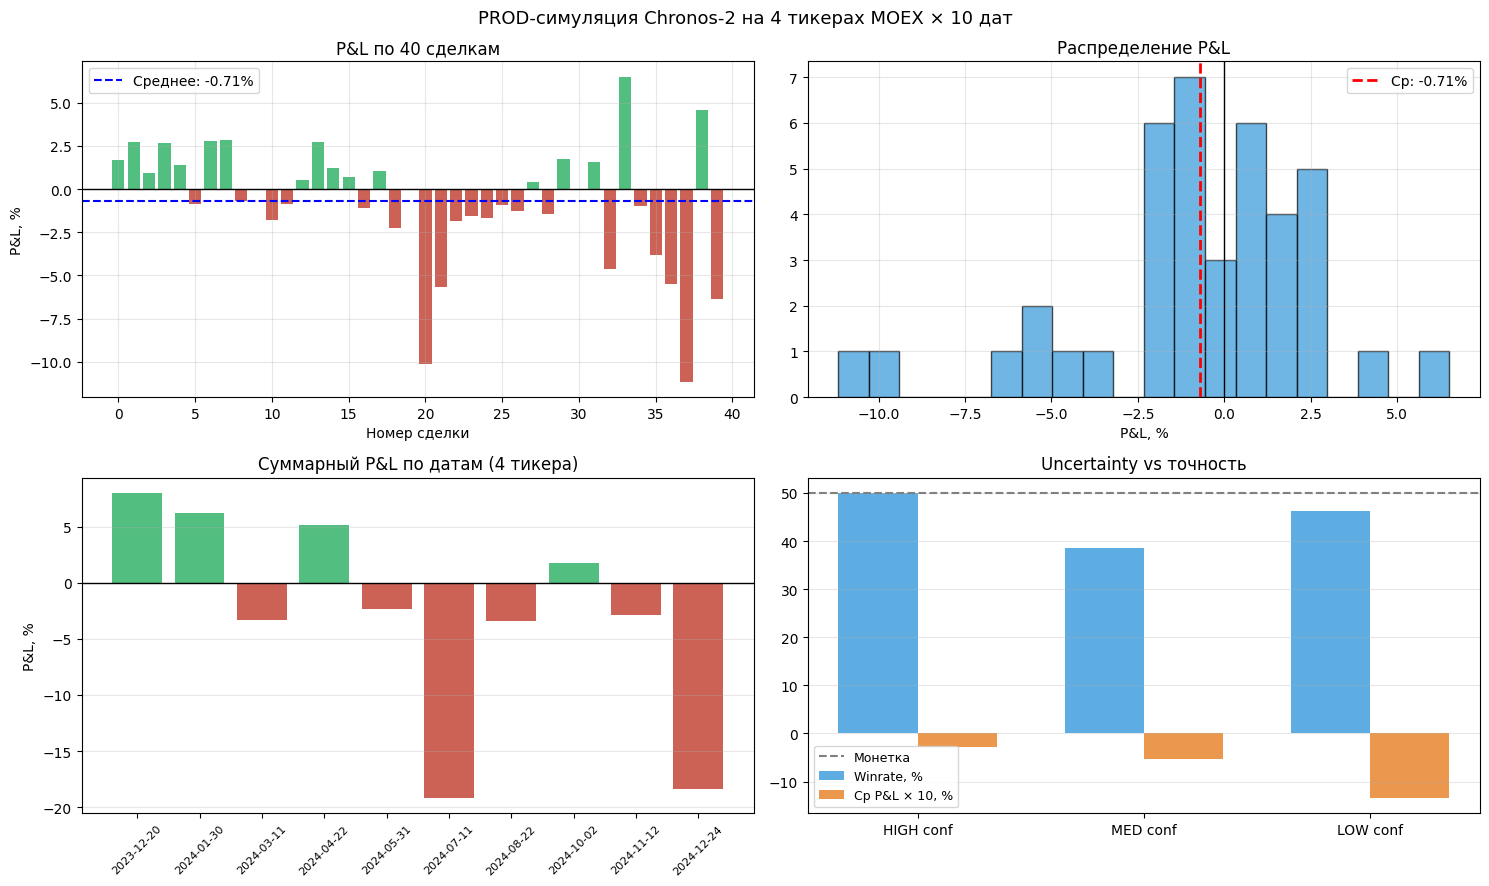

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. P&L по сделкам (распределение)
colors = ["#27ae60" if p > 0 else "#c0392b" for p in prod_log_df["pnl_%"]]
axes[0, 0].bar(range(len(prod_log_df)), prod_log_df["pnl_%"], color=colors, alpha=0.8)
axes[0, 0].axhline(0, color="black", lw=1)
axes[0, 0].axhline(prod_log_df["pnl_%"].mean(), color="blue", ls="--",
                   label=f"Среднее: {prod_log_df['pnl_%'].mean():+.2f}%")
axes[0, 0].set_title(f"P&L по {len(prod_log_df)} сделкам")
axes[0, 0].set_xlabel("Номер сделки"); axes[0, 0].set_ylabel("P&L, %")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2. Гистограмма P&L
axes[0, 1].hist(prod_log_df["pnl_%"], bins=20, color="#3498db", alpha=0.7, edgecolor="black")
axes[0, 1].axvline(0, color="black", lw=1)
axes[0, 1].axvline(prod_log_df["pnl_%"].mean(), color="red", ls="--", lw=2,
                   label=f"Ср: {prod_log_df['pnl_%'].mean():+.2f}%")
axes[0, 1].set_title("Распределение P&L")
axes[0, 1].set_xlabel("P&L, %"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# 3. P&L по датам
date_pnl = prod_log_df.groupby("date")["pnl_%"].sum()
date_colors = ["#27ae60" if p > 0 else "#c0392b" for p in date_pnl.values]
axes[1, 0].bar(range(len(date_pnl)), date_pnl.values, color=date_colors, alpha=0.8)
axes[1, 0].set_xticks(range(len(date_pnl)))
axes[1, 0].set_xticklabels([str(d) for d in date_pnl.index], rotation=45, fontsize=8)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_title("Суммарный P&L по датам (4 тикера)")
axes[1, 0].set_ylabel("P&L, %"); axes[1, 0].grid(alpha=0.3, axis="y")

# 4. Uncertainty vs P&L
conf_summary = prod_log_df.groupby("confidence", observed=True).agg(
    pnl_mean=("pnl_%", "mean"),
    winrate=("correct_dir", lambda x: x.mean() * 100),
    n=("pnl_%", "count"),
).reindex(["HIGH", "MED", "LOW"])

x = np.arange(3)
w = 0.35
axes[1, 1].bar(x - w/2, conf_summary["winrate"], w, label="Winrate, %", color="#3498db", alpha=0.8)
axes[1, 1].bar(x + w/2, conf_summary["pnl_mean"]*10, w,
               label="Ср P&L × 10, %", color="#e67e22", alpha=0.8)
axes[1, 1].axhline(50, color="gray", ls="--", label="Монетка")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(["HIGH conf", "MED conf", "LOW conf"])
axes[1, 1].set_title("Uncertainty vs точность")
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(alpha=0.3, axis="y")

plt.suptitle(f"PROD-симуляция Chronos-2 на 4 тикерах MOEX × {N_DATES} дат", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
TICKERS = ["SBER", "GAZP", "LKOH", "ROSN", "GMKN", "MTSS", "MAGN", "PLZL"]
N_DATES = 20
HORIZON = 5
CONTEXT_LEN = 250

# Кэшируем все цены
print("Кэшируем данные по 8 тикерам...")
ticker_data = {}
for tic in TICKERS:
    try:
        data = fetch_moex_candles(tic, DATE_FROM, DATE_TILL, INTERVAL)
        prices = (
            data.set_index("begin")["close"]
            .astype(float)
            .asfreq("B")
            .ffill()
        )
        log_returns = np.log(prices / prices.shift(1)).dropna()
        if len(log_returns) >= CONTEXT_LEN + HORIZON + 50:
            ticker_data[tic] = {"prices": prices, "log_returns": log_returns}
            print(f"  {tic}: {len(log_returns)} точек ✓")
        else:
            print(f"  {tic}: мало данных, пропуск")
    except Exception as e:
        print(f"  {tic}: ошибка {e}")

# 20 дат равномерно
ref_returns = ticker_data["SBER"]["log_returns"]
date_indices = np.linspace(CONTEXT_LEN, len(ref_returns) - HORIZON, N_DATES, dtype=int)
test_dates = [ref_returns.index[i] for i in date_indices]
print(f"\n{len(test_dates)} тестовых дат: {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"Всего прогонов: {len(test_dates) * len(ticker_data)}")

Кэшируем данные по 8 тикерам...
  SBER: 519 точек ✓
  GAZP: 519 точек ✓
  LKOH: 519 точек ✓
  ROSN: 519 точек ✓
  GMKN: 519 точек ✓
  MTSS: 519 точек ✓
  MAGN: 519 точек ✓
  PLZL: 519 точек ✓

20 тестовых дат: 2023-12-20 → 2024-12-24
Всего прогонов: 160


In [ ]:
big_log = []

for test_date in tqdm(test_dates, desc="Даты"):
    for tic in ticker_data:
        log_returns = ticker_data[tic]["log_returns"]
        prices = ticker_data[tic]["prices"]

        if test_date not in log_returns.index:
            continue
        pos = log_returns.index.get_loc(test_date)
        if pos < CONTEXT_LEN or pos + HORIZON > len(log_returns):
            continue

        ctx_returns = log_returns.iloc[pos - CONTEXT_LEN:pos]
        test_returns = log_returns.iloc[pos:pos + HORIZON]

        ctx_input = pd.DataFrame({
            "id": tic, "timestamp": ctx_returns.index, "target": ctx_returns.values,
        })
        pred = pipeline.predict_df(
            ctx_input, prediction_length=HORIZON, quantile_levels=QUANTILES,
            id_column="id", timestamp_column="timestamp", target="target",
        )

        y_pred_returns = pred["0.5"].values
        y_true_returns = test_returns.values
        cum_pred = np.exp(y_pred_returns.sum()) - 1
        cum_true = np.exp(y_true_returns.sum()) - 1

        direction = "LONG" if cum_pred > 0 else "SHORT" if cum_pred < 0 else "HOLD"
        pnl = cum_true if direction == "LONG" else (-cum_true if direction == "SHORT" else 0)
        coridor_width = (pred["0.9"].values - pred["0.1"].values).mean()

        big_log.append({
            "date": test_date.date(), "ticker": tic,
            "pred_return_%": cum_pred * 100, "actual_return_%": cum_true * 100,
            "direction": direction, "correct_dir": np.sign(cum_pred) == np.sign(cum_true),
            "pnl_%": pnl * 100, "coridor_width_%": coridor_width * 100,
        })

big_df = pd.DataFrame(big_log)
print(f"\nГотово: {len(big_df)} сделок ({big_df['ticker'].nunique()} тикеров × {big_df['date'].nunique()} дат)")

Даты: 100%|██████████| 20/20 [00:30<00:00,  1.52s/it]


Готово: 160 сделок (8 тикеров × 20 дат)


In [ ]:
# HIGH = нижняя треть по ширине коридора (самые уверенные)
high_threshold = big_df["coridor_width_%"].quantile(0.33)
big_df["is_high_conf"] = big_df["coridor_width_%"] <= high_threshold
print(f"Порог HIGH confidence: коридор ≤ {high_threshold:.2f}%")
print(f"Сделок HIGH conf: {big_df['is_high_conf'].sum()}/{len(big_df)} ({big_df['is_high_conf'].mean()*100:.0f}%)")

# === Три стратегии ===
strategies = {
    "All trades": big_df,
    "HIGH conf only": big_df[big_df["is_high_conf"]],
    "Buy & Hold (рынок)": None,  # отдельно
}

# Buy & Hold — берём то же количество дат и тикеров, считаем среднюю доходность
bh_returns = big_df.groupby(["date", "ticker"])["actual_return_%"].first()
buyhold_avg = bh_returns.mean()  # среднее по 160 «держим лонг»
buyhold_total = bh_returns.sum()

print("\n" + "=" * 80)
print(f"Сравнение стратегий ({len(big_df)} сделок: {big_df['ticker'].nunique()} тикеров × {N_DATES} дат)")
print("=" * 80)
print(f"\n{'Стратегия':<25} {'Сделок':>8} {'Winrate':>10} {'Ср P&L':>10} {'Сум P&L':>12} {'Sharpe':>10}")
print("-" * 80)

stats = {}
for name, sub in strategies.items():
    if name == "Buy & Hold (рынок)":
        n = len(bh_returns)
        wr = (bh_returns > 0).mean() * 100
        avg = buyhold_avg
        total = buyhold_total
        sharpe = bh_returns.mean() / bh_returns.std() * np.sqrt(52) if bh_returns.std() > 0 else 0
    else:
        n = len(sub)
        wr = sub["correct_dir"].mean() * 100
        avg = sub["pnl_%"].mean()
        total = sub["pnl_%"].sum()
        sharpe = sub["pnl_%"].mean() / sub["pnl_%"].std() * np.sqrt(52) if sub["pnl_%"].std() > 0 else 0
    stats[name] = {"n": n, "wr": wr, "avg": avg, "total": total, "sharpe": sharpe}
    print(f"{name:<25} {n:>8} {wr:>9.1f}% {avg:>+9.2f}% {total:>+11.2f}% {sharpe:>10.2f}")

# Дельта между стратегиями
print(f"\n=== Эффект фильтра HIGH conf ===")
all_avg, high_avg = stats["All trades"]["avg"], stats["HIGH conf only"]["avg"]
all_total, high_total = stats["All trades"]["total"], stats["HIGH conf only"]["total"]
print(f"Ср P&L:   {all_avg:+.2f}% → {high_avg:+.2f}%  (Δ = {high_avg - all_avg:+.2f} п.п.)")
print(f"Сум P&L:  {all_total:+.2f}% → {high_total:+.2f}%  (фильтр сэкономил {all_total - high_total:+.2f}%)")

Порог HIGH confidence: коридор ≤ 2.73%
Сделок HIGH conf: 53/160 (33%)

Сравнение стратегий (160 сделок: 8 тикеров × 20 дат)

Стратегия                   Сделок    Winrate     Ср P&L      Сум P&L     Sharpe
--------------------------------------------------------------------------------
All trades                     160      56.2%     +0.40%      +63.45%       0.70
HIGH conf only                  53      56.6%     +0.32%      +16.78%       0.91
Buy & Hold (рынок)             160      45.6%     -0.42%      -67.63%      -0.75

=== Эффект фильтра HIGH conf ===
Ср P&L:   +0.40% → +0.32%  (Δ = -0.08 п.п.)
Сум P&L:  +63.45% → +16.78%  (фильтр сэкономил +46.67%)


In [ ]:
# По тикерам
print("\n=== По тикерам (All vs HIGH only) ===")
print(f"{'Тикер':<8} {'All WR':>8} {'All P&L':>10} {'HIGH WR':>10} {'HIGH P&L':>11} {'Δ':>10}")
print("-" * 65)
for tic in ticker_data:
    sub_all = big_df[big_df["ticker"] == tic]
    sub_high = big_df[(big_df["ticker"] == tic) & big_df["is_high_conf"]]
    if len(sub_high) == 0:
        continue
    all_wr = sub_all["correct_dir"].mean() * 100
    all_pl = sub_all["pnl_%"].mean()
    high_wr = sub_high["correct_dir"].mean() * 100
    high_pl = sub_high["pnl_%"].mean()
    print(f"{tic:<8} {all_wr:>7.0f}% {all_pl:>+9.2f}% "
          f"{high_wr:>9.0f}% {high_pl:>+10.2f}% {high_pl - all_pl:>+9.2f}")


=== По тикерам (All vs HIGH only) ===
Тикер      All WR    All P&L    HIGH WR    HIGH P&L          Δ
-----------------------------------------------------------------
SBER          55%     +0.34%        64%      +0.36%     +0.02
GAZP          60%     +0.27%        62%      +0.51%     +0.25
LKOH          50%     +0.35%        50%      -0.10%     -0.45
ROSN          60%     +0.39%        33%      -1.39%     -1.78
GMKN          50%     +0.72%        44%      +0.28%     -0.44
MTSS          70%     +0.47%        75%      +1.46%     +0.99
PLZL          65%     +0.14%       100%      +3.85%     +3.71


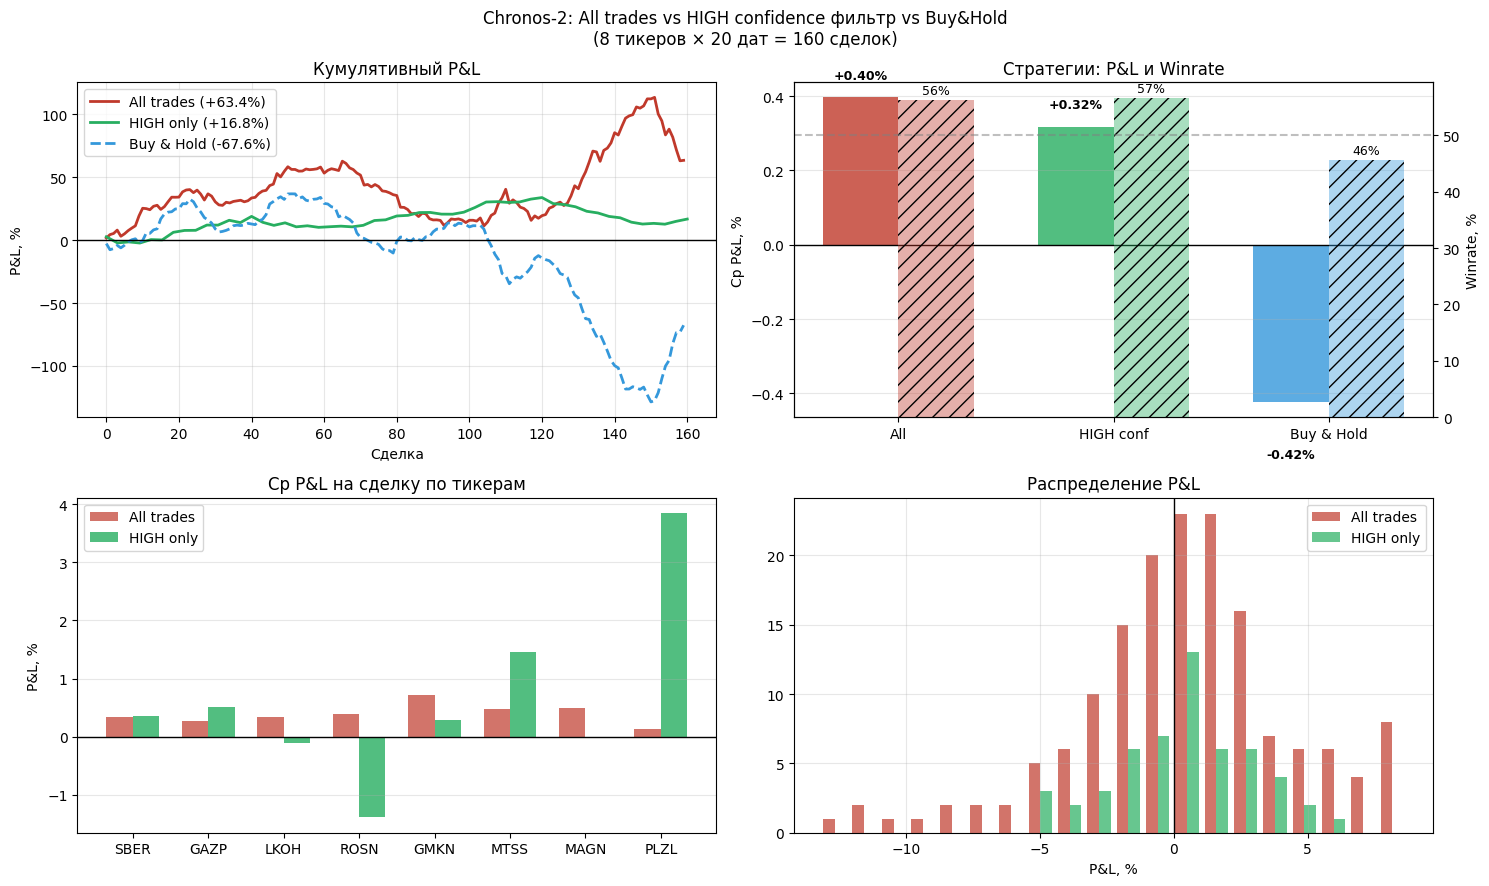

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. Кумулятивный P&L во времени
all_sorted = big_df.sort_values("date")
all_sorted["cum_pnl"] = all_sorted["pnl_%"].cumsum()
high_sorted = big_df[big_df["is_high_conf"]].sort_values("date")
high_sorted["cum_pnl"] = high_sorted["pnl_%"].cumsum()
bh_sorted = bh_returns.reset_index().sort_values("date")
bh_sorted["cum_pnl"] = bh_sorted["actual_return_%"].cumsum()

axes[0, 0].plot(range(len(all_sorted)), all_sorted["cum_pnl"].values,
                label=f"All trades ({stats['All trades']['total']:+.1f}%)", color="#c0392b", lw=2)
axes[0, 0].plot(np.linspace(0, len(all_sorted), len(high_sorted)), high_sorted["cum_pnl"].values,
                label=f"HIGH only ({stats['HIGH conf only']['total']:+.1f}%)", color="#27ae60", lw=2)
axes[0, 0].plot(range(len(bh_sorted)), bh_sorted["cum_pnl"].values,
                label=f"Buy & Hold ({buyhold_total:+.1f}%)", color="#3498db", lw=2, ls="--")
axes[0, 0].axhline(0, color="black", lw=1)
axes[0, 0].set_title("Кумулятивный P&L")
axes[0, 0].set_xlabel("Сделка"); axes[0, 0].set_ylabel("P&L, %")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# 2. Bar сравнения средних P&L
strat_names = ["All", "HIGH conf", "Buy & Hold"]
strat_pnl = [stats["All trades"]["avg"], stats["HIGH conf only"]["avg"], buyhold_avg]
strat_wr = [stats["All trades"]["wr"], stats["HIGH conf only"]["wr"], stats["Buy & Hold (рынок)"]["wr"]]
colors = ["#c0392b", "#27ae60", "#3498db"]
x = np.arange(3); w = 0.35
b1 = axes[0, 1].bar(x - w/2, strat_pnl, w, color=colors, alpha=0.8, label="Ср P&L, %")
ax2 = axes[0, 1].twinx()
b2 = ax2.bar(x + w/2, strat_wr, w, color=colors, alpha=0.4, label="Winrate, %", hatch="//")
axes[0, 1].axhline(0, color="black", lw=1)
ax2.axhline(50, color="gray", ls="--", alpha=0.5)
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(strat_names)
axes[0, 1].set_ylabel("Ср P&L, %"); ax2.set_ylabel("Winrate, %")
axes[0, 1].set_title("Стратегии: P&L и Winrate")
for i, (p, w_v) in enumerate(zip(strat_pnl, strat_wr)):
    axes[0, 1].text(i - w/2, p + (0.05 if p >= 0 else -0.15), f"{p:+.2f}%", ha="center", fontsize=9, fontweight="bold")
    ax2.text(i + w/2, w_v + 1, f"{w_v:.0f}%", ha="center", fontsize=9)
axes[0, 1].grid(alpha=0.3, axis="y")

# 3. P&L по тикерам: All vs HIGH
ticker_list = list(ticker_data.keys())
all_pnl_t = [big_df[big_df["ticker"] == t]["pnl_%"].mean() for t in ticker_list]
high_pnl_t = [big_df[(big_df["ticker"] == t) & big_df["is_high_conf"]]["pnl_%"].mean()
              if (big_df[(big_df["ticker"] == t) & big_df["is_high_conf"]]).shape[0] > 0 else 0
              for t in ticker_list]
x = np.arange(len(ticker_list)); w = 0.35
axes[1, 0].bar(x - w/2, all_pnl_t, w, label="All trades", color="#c0392b", alpha=0.7)
axes[1, 0].bar(x + w/2, high_pnl_t, w, label="HIGH only", color="#27ae60", alpha=0.8)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(ticker_list)
axes[1, 0].set_title("Ср P&L на сделку по тикерам")
axes[1, 0].set_ylabel("P&L, %"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3, axis="y")

# 4. Распределение P&L: All vs HIGH
axes[1, 1].hist([big_df["pnl_%"], big_df[big_df["is_high_conf"]]["pnl_%"]],
                bins=20, label=["All trades", "HIGH only"],
                color=["#c0392b", "#27ae60"], alpha=0.7)
axes[1, 1].axvline(0, color="black", lw=1)
axes[1, 1].set_title("Распределение P&L")
axes[1, 1].set_xlabel("P&L, %"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle(
    f"Chronos-2: All trades vs HIGH confidence фильтр vs Buy&Hold\n"
    f"({big_df['ticker'].nunique()} тикеров × {N_DATES} дат = {len(big_df)} сделок)",
    fontsize=12,
)
plt.tight_layout(); plt.show()

In [ ]:
!git clone https://github.com/shiyu-coder/Kronos.git
import sys
sys.path.insert(0, "/content/Kronos")  # для Colab. Если локально — скорректируйте путь

# Проверяем что импорт работает
from model import Kronos, KronosTokenizer, KronosPredictor
print("Kronos импортирован ✓")

Cloning into 'Kronos'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 371 (delta 6), reused 3 (delta 3), pack-reused 360 (from 2)
Receiving objects: 100% (371/371), 9.32 MiB | 21.69 MiB/s, done.
Resolving deltas: 100% (174/174), done.
Kronos импортирован ✓


In [ ]:
print("Загружаем Kronos-small (это первый раз ~30-60 сек)...")
tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
kronos_model = Kronos.from_pretrained("NeoQuasar/Kronos-small")
kronos_predictor = KronosPredictor(kronos_model, tokenizer, device="cpu", max_context=512)
print("Kronos готов ✓")

Загружаем Kronos-small (это первый раз ~30-60 сек)...


config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Kronos готов ✓


In [ ]:
def predict_kronos(ticker_df, ctx_end_idx, horizon, lookback=250):
    """
    ticker_df: исходный DataFrame с колонками open/high/low/close/volume и begin
    ctx_end_idx: индекс последней точки контекста
    Возвращает: y_pred_returns (массив log-returns на горизонте), y_pred_prices

    Kronos требует OHLCV — поэтому работаем с исходным df, не с full_ts.
    """
    ctx = ticker_df.iloc[ctx_end_idx - lookback:ctx_end_idx].copy()

    # Нужны таймстемпы будущих периодов (Kronos этого требует)
    last_ts = ctx["begin"].iloc[-1]
    future_ts = pd.bdate_range(start=last_ts + pd.Timedelta(days=1), periods=horizon)

    # Прогноз
    pred_df = kronos_predictor.predict(
        df=ctx[["open", "high", "low", "close", "volume"]],
        x_timestamp=ctx["begin"],
        y_timestamp=pd.Series(future_ts),
        pred_len=horizon,
        T=1.0,           # температура
        top_p=0.9,
        sample_count=5,  # Monte Carlo для probabilistic
    )
    # pred_df содержит open/high/low/close/volume на горизонте

    last_price = ctx["close"].iloc[-1]
    pred_prices = pred_df["close"].values
    pred_returns = np.log(pred_prices / np.concatenate([[last_price], pred_prices[:-1]]))
    return pred_returns, pred_prices

In [ ]:
results_kronos = []

for test_date in tqdm(test_dates, desc="Kronos прогон"):
    for tic in ticker_data:
        # Тянем исходный df с OHLCV (нужен для Kronos)
        raw_df = fetch_moex_candles(tic, DATE_FROM, DATE_TILL, INTERVAL)
        raw_df = raw_df.sort_values("begin").reset_index(drop=True)

        # Находим позицию test_date
        if test_date.date() not in [d.date() for d in raw_df["begin"]]:
            continue
        pos = raw_df[raw_df["begin"].dt.date == test_date.date()].index[0]

        if pos < CONTEXT_LEN or pos + HORIZON > len(raw_df):
            continue

        try:
            y_pred_returns, y_pred_prices = predict_kronos(
                raw_df, ctx_end_idx=pos, horizon=HORIZON, lookback=CONTEXT_LEN
            )
        except Exception as e:
            print(f"  {tic} {test_date.date()}: {e}")
            continue

        # Факт
        last_price = raw_df["close"].iloc[pos - 1]
        true_prices = raw_df["close"].iloc[pos:pos + HORIZON].values
        y_true_returns = np.log(true_prices / np.concatenate([[last_price], true_prices[:-1]]))

        cum_pred = np.exp(y_pred_returns.sum()) - 1
        cum_true = np.exp(y_true_returns.sum()) - 1
        direction = "LONG" if cum_pred > 0 else "SHORT" if cum_pred < 0 else "HOLD"
        pnl = cum_true if direction == "LONG" else (-cum_true if direction == "SHORT" else 0)

        results_kronos.append({
            "date": test_date.date(), "ticker": tic,
            "pred_return_%": cum_pred * 100, "actual_return_%": cum_true * 100,
            "direction": direction, "correct_dir": np.sign(cum_pred) == np.sign(cum_true),
            "pnl_%": pnl * 100,
        })

kronos_df = pd.DataFrame(results_kronos)
print(f"\nKronos готов: {len(kronos_df)} сделок")

100%|██████████| 5/5 [00:11<00:00,  2.30s/it]

100%|██████████| 5/5 [00:11<00:00,  2.24s/it]

100%|██████████| 5/5 [00:11<00:00,  2.25s/it]

100%|██████████| 5/5 [00:11<00:00,  2.26s/it]

100%|██████████| 5/5 [00:11<00:00,  2.25s/it]

100%|██████████| 5/5 [00:11<00:00,  2.23s/it]

100%|██████████| 5/5 [00:11<00:00,  2.24s/it]

100%|██████████| 5/5 [00:10<00:00,  2.17s/it]

100%|██████████| 5/5 [00:10<00:00,  2.10s/it]

100%|██████████| 5/5 [00:10<00:00,  2.02s/it]

100%|██████████| 5/5 [00:10<00:00,  2.02s/it]

100%|██████████| 5/5 [00:10<00:00,  2.08s/it]

100%|██████████| 5/5 [00:10<00:00,  2.13s/it]

100%|██████████| 5/5 [00:10<00:00,  2.19s/it]

100%|██████████| 5/5 [00:11<00:00,  2.23s/it]

100%|██████████| 5/5 [00:11<00:00,  2.23s/it]

100%|██████████| 5/5 [00:11<00:00,  2.23s/it]

100%|██████████| 5/5 [00:11<00:00,  2.24s/it]

100%|██████████| 5/5 [00:11<00:00,  2.25s/it]

100%|██████████| 5/5 [00:11<00:00,  2.23s/it]

100%|██████████| 5/5 [00:11<00:00,  2.22s/it]

100%|████████

Chronos-2 vs Kronos на 160 сделках (8 тикеров × 20 дат)

Стратегия                   Сделок    Winrate     Ср P&L      Сум P&L     Sharpe
--------------------------------------------------------------------------------
Chronos-2 (All)                160      56.2%     +0.40%      +63.45%       0.70
Kronos (All)                   144      42.4%     -0.77%     -110.18%      -1.42

=== По тикерам (Chronos vs Kronos) ===
Тикер      Chronos WR    Chronos P&L    Kronos WR     Kronos P&L
-----------------------------------------------------------------
SBER              55%         +0.34%          39%         -1.08%
GAZP              60%         +0.27%          50%         +0.66%
LKOH              50%         +0.35%          39%         -0.54%
ROSN              60%         +0.39%          56%         -0.16%
GMKN              50%         +0.72%          44%         -0.98%
MTSS              70%         +0.47%          22%         -1.47%
MAGN              40%         +0.49%          50%         

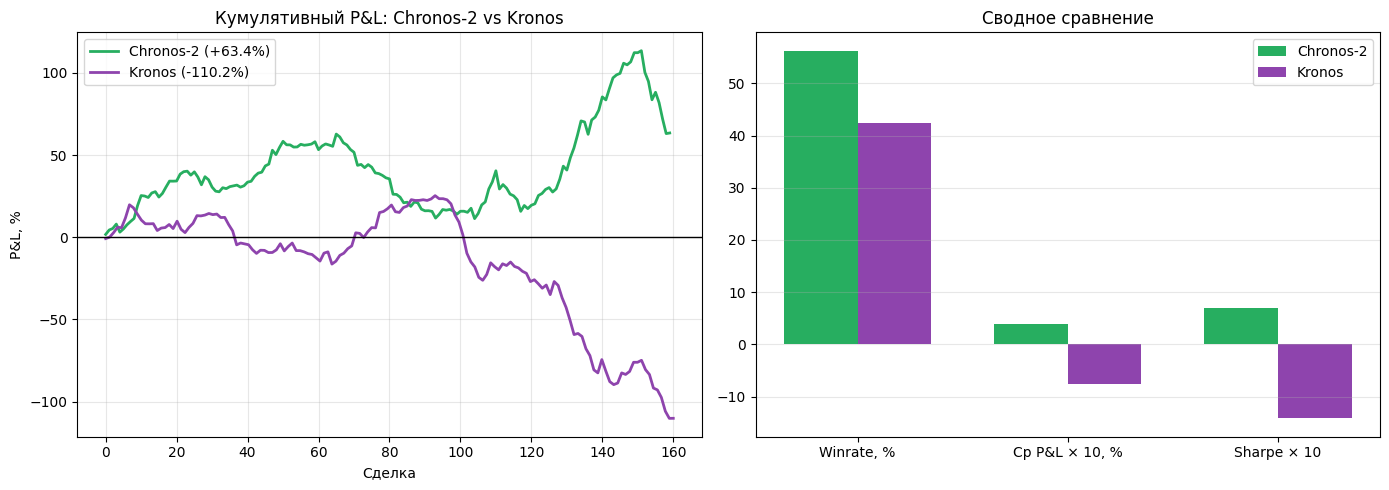

In [ ]:
print("=" * 80)
print(f"Chronos-2 vs Kronos на {len(big_df)} сделках (8 тикеров × 20 дат)")
print("=" * 80)
print(f"\n{'Стратегия':<25} {'Сделок':>8} {'Winrate':>10} {'Ср P&L':>10} {'Сум P&L':>12} {'Sharpe':>10}")
print("-" * 80)

for name, sub in [("Chronos-2 (All)", big_df), ("Kronos (All)", kronos_df)]:
    n = len(sub)
    wr = sub["correct_dir"].mean() * 100
    avg = sub["pnl_%"].mean()
    total = sub["pnl_%"].sum()
    sharpe = sub["pnl_%"].mean() / sub["pnl_%"].std() * np.sqrt(52) if sub["pnl_%"].std() > 0 else 0
    print(f"{name:<25} {n:>8} {wr:>9.1f}% {avg:>+9.2f}% {total:>+11.2f}% {sharpe:>10.2f}")

# По тикерам
print("\n=== По тикерам (Chronos vs Kronos) ===")
print(f"{'Тикер':<8} {'Chronos WR':>12} {'Chronos P&L':>14} {'Kronos WR':>12} {'Kronos P&L':>14}")
print("-" * 65)
for tic in TICKERS:
    c = big_df[big_df["ticker"] == tic]
    k = kronos_df[kronos_df["ticker"] == tic]
    if len(c) == 0 or len(k) == 0:
        continue
    print(f"{tic:<8} {c['correct_dir'].mean()*100:>11.0f}% {c['pnl_%'].mean():>+13.2f}% "
          f"{k['correct_dir'].mean()*100:>11.0f}% {k['pnl_%'].mean():>+13.2f}%")

# График
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Кумулятивный P&L
chronos_cum = big_df.sort_values("date")["pnl_%"].cumsum().values
kronos_cum = kronos_df.sort_values("date")["pnl_%"].cumsum().values
axes[0].plot(range(len(chronos_cum)), chronos_cum, label=f"Chronos-2 ({chronos_cum[-1]:+.1f}%)", color="#27ae60", lw=2)
axes[0].plot(np.linspace(0, len(chronos_cum), len(kronos_cum)), kronos_cum,
             label=f"Kronos ({kronos_cum[-1]:+.1f}%)", color="#8e44ad", lw=2)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Кумулятивный P&L: Chronos-2 vs Kronos")
axes[0].set_xlabel("Сделка"); axes[0].set_ylabel("P&L, %"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Сводное сравнение
metrics = ["Winrate, %", "Ср P&L × 10, %", "Sharpe × 10"]
chronos_vals = [
    big_df["correct_dir"].mean()*100,
    big_df["pnl_%"].mean()*10,
    (big_df["pnl_%"].mean() / big_df["pnl_%"].std() * np.sqrt(52))*10,
]
kronos_vals = [
    kronos_df["correct_dir"].mean()*100,
    kronos_df["pnl_%"].mean()*10,
    (kronos_df["pnl_%"].mean() / kronos_df["pnl_%"].std() * np.sqrt(52))*10,
]
x = np.arange(3); w = 0.35
axes[1].bar(x - w/2, chronos_vals, w, label="Chronos-2", color="#27ae60")
axes[1].bar(x + w/2, kronos_vals, w, label="Kronos", color="#8e44ad")
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_title("Сводное сравнение"); axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()